# Multi-shot Variable-Density Spiral SE Diffusion

This notebook builds a multi-shot spin-echo diffusion sequence with a variable-density spiral readout in the local pSeq framework.

## Outline
1. Configure protocol and hardware limits.
2. Build RF/fat-sat and VDS spiral readout blocks.
3. Define diffusion directions.
4. Assemble the full multi-slice, multi-direction diffusion sequence.
5. Run timing QA and export the sequence.

## Design Notes
- VDS profile follows a constrained radial-spiral integration with gradient and slew limits.
- FOV profile is polynomial in normalized radius (`fov_coeff`).
- Interleaves are generated by rotating a base trajectory by `2*pi/n_shots`.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import pypulseq as pp
from pSeq import (
    pSeq_Base,
    pSeq_RF,
    pSeq_FatSat,
    pSeq_Diffusion,
    pSeq_Spiral_VDS,
    pSeq_GRE_multi_echo
)

In [43]:
# ------------------------------
# User-facing protocol parameters
# ------------------------------
fov = 210e-3
nx = 140
ny = 140
n_shots = 3

# Spiral acceleration factor (in-plane undersampling).
# Typical useful range for blur reduction: 2.0 - 4.0
# spiral_accel = 2.0
# spiral_accel = 1.5
spiral_accel = 1.0
adc_dwell_s = 1e-6

# Variable-density FOV profile: F(r) = fov * (c0 + c1*x + c2*x^2 + ...), x=r/rmax
# Keep profile positive over x in [0, 1].
fov_coeff = [1.0, 0.0, -0.35]

n_slices = 3
slice_thickness = 5e-3
slice_gap = 10e-3
slice_offsets = (np.arange(n_slices) - (n_slices - 1) / 2.0) * (slice_thickness + slice_gap)

# num_repeats = 8
num_repeats = 1
TR_sec = 500e-3
b_value = 2000
# b_value = 2000
# b_value = 10000

# Optional shot-level spoiling for residual transverse cleanup.
enable_rf_spoil = False
rf_spoil_inc_deg = 117.0
enable_grad_spoil = True
grad_spoil_cycles_per_voxel = 20.0

print(f'FOV={fov*1e3:.1f} mm, Matrix={nx}x{ny}, Shots={n_shots}')
print(f'Spiral acceleration={spiral_accel:.2f}x')
print(f'FOV coeff={fov_coeff}')
print(f'Slices={n_slices}, Repeat={num_repeats}, b={b_value} s/mm^2')
print(f'RF spoil={enable_rf_spoil} (inc={rf_spoil_inc_deg:.1f} deg)')
print(f'Grad spoil={enable_grad_spoil} (cycles/voxel={grad_spoil_cycles_per_voxel:.1f})')

FOV=210.0 mm, Matrix=140x140, Shots=3
Spiral acceleration=1.00x
FOV coeff=[1.0, 0.0, -0.35]
Slices=3, Repeat=1, b=2000 s/mm^2
RF spoil=False (inc=117.0 deg)
Grad spoil=True (cycles/voxel=20.0)


In [44]:
# --------------------------------------------------------
# Build hardware limits and reusable RF/FatSat blocks
# --------------------------------------------------------
system_max = pp.Opts(
    max_grad=200, grad_unit='mT/m',
    max_slew=200, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

# system_diff = pp.Opts(
#     max_grad=160, grad_unit='mT/m',
#     max_slew=80, slew_unit='T/m/s',
#     rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
# )
system_diff = pp.Opts(
    max_grad=200, grad_unit='mT/m',
    max_slew=70, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_spiral = pp.Opts(
    max_grad=100, grad_unit='mT/m',
    max_slew=70, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_rf = pp.Opts(
    max_grad=100, grad_unit='mT/m',
    max_slew=50, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

system_low = pp.Opts(
    max_grad=30, grad_unit='mT/m',
    max_slew=30, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_sp = pSeq_Base(system=system_max)

fatsat = pSeq_FatSat(system=system_low, type='FatSat2')
fatsat.prep_fatsat()

rf90 = pSeq_RF(
    system=system_rf,
    flip_angle=np.pi / 2,
    duration=3e-3,
    thickness=slice_thickness,
    use='excitation',
)
rf90.prep()

rf180 = pSeq_RF(
    system=system_rf,
    flip_angle=np.pi,
    duration=6e-3,
    thickness=slice_thickness,
    use='refocusing',
    do_refocus=False,
    crusher_area=1000,
    # crusher_axis=['x', 'y', 'z'],
    crusher_axis=['z'],
)
rf180.prep()

trig = pp.make_digital_output_pulse('ext1', duration=20e-6)

-220.3308
0.003 0.003
-220.3308
Fat Sat: The peak rf_fs Amplitude =  1.6253962983488777e-06 uT
Making Sinc Pulse with flip angle 90.0
Making SLR Pulse with flip angle 90.0
excitation : The peak rf Amplitude =  7.797889527969152 uT
Making Sinc Pulse with flip angle 180.0
Making SLR Pulse with flip angle 180.0
refocusing : The peak rf Amplitude =  7.797889596354154 uT
Prepared crusher gradients for refocusing pulse on ['z']-axis with area 1000 1/m


Spiral summary: {'adc_samples': 27928, 'adc_dwell': 1e-06, 'adc_bandwidth_hz': 1000000.0, 'center_hold_duration': 3.0000000000000004e-05, 'accel_requested': 1.0, 'accel_effective': 1.0, 'readout_duration': 0.027950000000000003, 'rampdown_duration': 0.0002699999999999994, 'rewinder_duration': 0.0006600000000000001, 'shot_duration': 0.028880000000000003, 'kmax': 333.33333333333337}
Readout duration per shot: 27.95 ms
Total shot duration (with rewinder): 28.88 ms


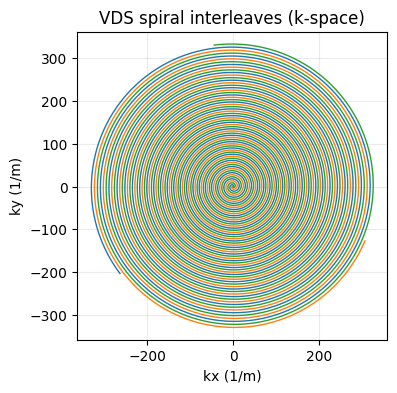

In [45]:
# --------------------------------------------------------
# Prepare multishot variable-density spiral readout
# --------------------------------------------------------
spiral_vds = pSeq_Spiral_VDS(
    system=system_spiral,
    fov=fov,
    nx=nx,
    ny=ny,
    n_interleaves=n_shots,
    fov_coeff=fov_coeff,
    accel=spiral_accel,
    oversamp=4,
)
summary = spiral_vds.prep(adc_dwell=adc_dwell_s)
print('Spiral summary:', summary)
print(f"Readout duration per shot: {summary['readout_duration']*1e3:.2f} ms")
print(f"Total shot duration (with rewinder): {summary['shot_duration']*1e3:.2f} ms")

k0 = spiral_vds.get_ktraj(interleaf=0)
plt.figure(figsize=(4, 4))
for shot_idx in range(n_shots):
    ks = spiral_vds.get_ktraj(interleaf=shot_idx)
    plt.plot(np.real(ks), np.imag(ks), lw=1.0, label=f'Shot {shot_idx}')
plt.title('VDS spiral interleaves (k-space)')
plt.xlabel('kx (1/m)')
plt.ylabel('ky (1/m)')
plt.axis('equal')
plt.grid(True, alpha=0.25)
# plt.legend(bbox_to_anchor=(1,1.1))
# plt.xlim(-1,1)
# plt.ylim(-1,1)
plt.show()

In [46]:
# -------------------------------------------------------------
# Fixed diffusion direction set (b0 + 6 cardinal directions)
# -------------------------------------------------------------
diff_dirs = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [-1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, -1.0, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, -1.0],
], dtype=float)

dir_labels = ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']
num_dirs = diff_dirs.shape[0]
print('Using diffusion directions:', dir_labels)

Using diffusion directions: ['b0', 'x+', 'x-', 'y+', 'y-', 'z+', 'z-']


In [47]:
# ---------------------------------------------------------------------
# Sequence assembly (multi-slice diffusion with multishot VDS spiral)
# Loop order: repeat -> slice -> direction -> shot
# ---------------------------------------------------------------------
seq_sp = pSeq_Base(system=system_max)

diffusion = pSeq_Diffusion(
    system=system_diff,
    channel='x',
    target_b_s_mm2=b_value,
    max_lobe_duration=40e-3,
)

_ = diffusion.prep_monopolar(
    rf90=rf90,
    rf180=rf180,
    epi=spiral_vds,
    extra_pre_delay_s=0.0,
    verbose=True,
)

print(f'Designed diffusion b(actual): {diffusion.b_actual_s_mm2:.2f} s/mm^2')
print(f'Designed TE(min): {diffusion.te*1e3:.2f} ms')

spoil_area = grad_spoil_cycles_per_voxel / slice_thickness
if enable_grad_spoil:
    gx_spoil = pp.make_trapezoid(channel='x', system=system_low, area=spoil_area)
    gy_spoil = pp.make_trapezoid(channel='y', system=system_low, area=spoil_area)
    gz_spoil = pp.make_trapezoid(channel='z', system=system_low, area=spoil_area)

rf_spoil_phase_deg = 0.0
rf_spoil_inc_deg_state = 0.0

total_shots = 0
tr_violations = 0

for rep in tqdm(range(num_repeats)):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        for dir_idx, diff_dir in enumerate(diff_dirs):
            for shot_idx in range(n_shots):
                total_shots += 1
                t_start = seq_sp.seq.duration()[0] if len(seq_sp.seq.block_events) > 0 else 0.0

                rf90.offset_rf(offset=slc_offset)
                rf180.offset_rf(offset=slc_offset)
                if enable_rf_spoil:
                    rf_spoil_phase_deg = (rf_spoil_phase_deg + rf_spoil_inc_deg_state) % 360.0
                    rf_spoil_inc_deg_state = (rf_spoil_inc_deg_state + rf_spoil_inc_deg) % 360.0
                    rf_spoil_phase_rad = np.deg2rad(rf_spoil_phase_deg)
                    rf90.rf.phase_offset += rf_spoil_phase_rad
                    rf180.rf.phase_offset += rf_spoil_phase_rad
                    spiral_vds.adc.phase_offset = rf90.rf.phase_offset

                lrep = pp.make_label(type='SET', label='REP', value=rep)
                lslc = pp.make_label(type='SET', label='SLC', value=slc_idx)
                lseg = pp.make_label(type='SET', label='SEG', value=dir_idx)
                lavg = pp.make_label(type='SET', label='AVG', value=shot_idx)
                seq_sp.seq.add_block(lrep, lslc, lseg, lavg, trig)

                g0, g1 = diffusion.get_rotated_lobes(diff_dir)

                # seq_sp.add_pseq_to_self(fatsat)
                seq_sp.add_pseq_to_self(rf90)
                seq_sp.seq.add_block(*g0)

                if diffusion.delay1 > 0:
                    seq_sp.seq.add_block(pp.make_delay(diffusion.delay1))

                seq_sp.add_pseq_to_self(rf180)
                seq_sp.seq.add_block(*g1)

                if diffusion.delay2 > 0:
                    seq_sp.seq.add_block(pp.make_delay(diffusion.delay2))

                spiral_vds.add_to_seq(seq_sp, interleaf=shot_idx, label=False, add_rewinder=True)
                if enable_grad_spoil:
                    seq_sp.seq.add_block(gx_spoil, gy_spoil, gz_spoil)

                t_end = seq_sp.seq.duration()[0]
                shot_dur = t_end - t_start
                tr_pad = TR_sec - shot_dur

                if tr_pad > system_max.grad_raster_time:
                    tr_pad = np.ceil(tr_pad / system_max.grad_raster_time) * system_max.grad_raster_time
                    seq_sp.seq.add_block(pp.make_delay(tr_pad))
                elif tr_pad < -1e-6:
                    tr_violations += 1

print(f'Total shots added: {total_shots}')
print(f'TR violations: {tr_violations}')
print(f'Estimated sequence duration: {seq_sp.seq.duration()[0]:.2f} s')

Diffusion designer summary:
  target b: 2000.00 s/mm^2
  actual b: 2000.00 s/mm^2
  lobe amplitude: 8507725.465 Hz/m
  lobe duration: 9.050 ms
  delay1: 0.000 ms
  delay2: 2.550 ms
  pre-lobe delay: 2.529 ms
  inter-lobe delay: 11.480 ms
  TE(min): 32.139 ms
  spin-echo mismatch: -9.500 us
Designed diffusion b(actual): 2000.00 s/mm^2
Designed TE(min): 32.14 ms


  0%|          | 0/1 [00:00<?, ?it/s]

Total shots added: 63
TR violations: 0
Estimated sequence duration: 31.50 s


Timing check passed: True
Total sequence duration: 31.500 s


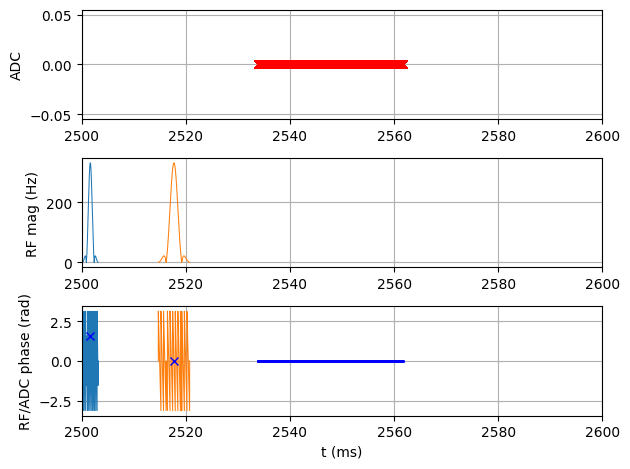

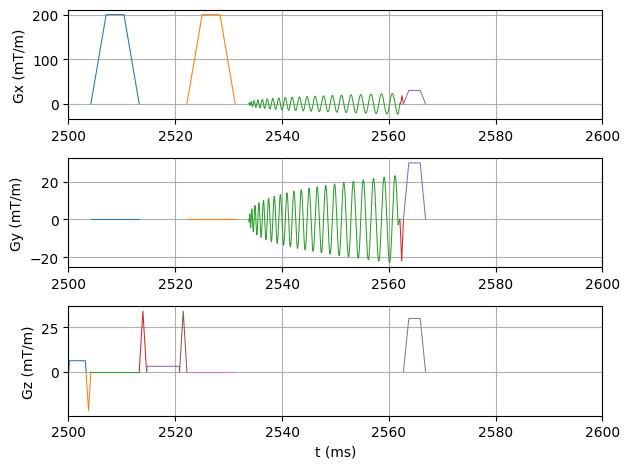

In [48]:
# ---------------------------------------
# Timing QA and quick visual inspection
# ---------------------------------------
ok, err = seq_sp.seq.check_timing()
print(f'Timing check passed: {ok}')
if not ok:
    print('First timing issues:')
    for item in err[:10]:
        print(' -', item)

print(f'Total sequence duration: {seq_sp.seq.duration()[0]:.3f} s')
seq_sp.seq.plot(time_range=[TR_sec*5, TR_sec*5 + 100e-3], grad_disp='mT/m', time_disp='ms')
plt.show()

In [49]:
# -----------------------------
# Export sequence to .seq file
# -----------------------------
# version = 'v0.7.2-highres'
# version = 'v0.7.2-highres-skope'
version = 'v0.9.0-midres'
out_dir = Path('seq')
out_dir.mkdir(parents=True, exist_ok=True)
accel_tag = str(spiral_accel)
out_name = (
    f'fs_se_dti_spiral_vds_b{int(b_value)}_'
    f'dir{num_dirs}_shot{n_shots}_slice{n_slices}_'
    f'acc{accel_tag}_{version}.seq'
)
out_path = out_dir / out_name

# seq_sp.seq.write(str(out_path))
print(f'Wrote sequence: {out_path}')

# Optional safety check: keep disabled by default to avoid long runtime.
run_safety_check = True
if run_safety_check:
    seq_sp.check_safety_lims(
        r'E:\\MGH\\Healthy_Grad\\asc\\CimaX.asc',
        time_range=[0, min(TR_sec, seq_sp.seq.duration()[0])],
        cns=True,
        do_plot=False,
    )
    print('Safety check complete.')

Wrote sequence: seq\fs_se_dti_spiral_vds_b2000_dir7_shot3_slice3_acc1.0_v0.9.0-midres.seq
PNS is OK
CNS is OK
Safety check complete.


In [50]:
# ------------------------------------------------------------------
# Multi-echo FLASH (GRE) sensitivity mapping sequence (new pSeq_Base)
# Geometry is matched to diffusion EPI: FOV, in-plane matrix, slices.
# ------------------------------------------------------------------
system_gre = pp.Opts(
    max_grad=120, grad_unit='mT/m',
    max_slew=100, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6, adc_dead_time=20e-6
)

seq_meflash = pSeq_Base(system=system_gre)
seq_meflash.init_seq()

gre_sens = pSeq_GRE_multi_echo(
    system=system_gre,
    fov=fov,
    nx=nx,
    ny=ny,
    slice_thickness=slice_thickness,
    flip_angle=np.deg2rad(5.0),
    rf_duration=0.8e-3,
    readout_time=1.28e-3,
    te1=2.46e-3,
    echo_spacing=2.46e-3,
    # echo_spacing=3.2e-3,
    tr=50e-3,
    n_echoes=4,
    readout_mode='monopolar',
    rf_spoil_inc_deg=117.0,
    spoiler_area_ro=1.0 / 1e-3,
    spoiler_area_pe=1.0 / 1e-3,
    spoiler_area_sl=1.0 / 1e-3,
 )
gre_sens.prep()

for rep_idx in range(1):
    for slc_idx, slc_offset in enumerate(slice_offsets):
        for lin_idx in range(ny):
            gre_sens.add_line_to_seq(
                seq_meflash,
                line_index=lin_idx,
                slice_offset=slc_offset,
                rep_idx=rep_idx,
                slc_idx=slc_idx,
                label=True,
            )

ok_me, err_me = seq_meflash.seq.check_timing()
print(f'ME-FLASH timing check passed: {ok_me}')
if not ok_me:
    print('First timing issues:')
    for item in err_me[:10]:
        print(' -', item)

me_timing = gre_sens.get_timing()
print(f"ME-FLASH nominal TR: {me_timing['tr_nominal']*1e3:.3f} ms")
print(f"TEs [ms]: {np.round((me_timing['te1'] + np.arange(me_timing['n_echoes']) * me_timing['echo_spacing']) * 1e3, 3)}")

Prepared multi-echo FLASH blocks:
  Matrix: 140x140, FOV: 210.0 mm
  Readout mode: monopolar
  Inter-echo rewind (constrained): 0.920 ms
  Inter-echo delay block: 0.000 ms
  Echoes: 4, TE1: 2.46 ms, dTE: 2.46 ms
  TR: 50.00 ms, TR fill: 37.17 ms
ME-FLASH timing check passed: True
ME-FLASH nominal TR: 50.000 ms
TEs [ms]: [2.46 4.92 7.38 9.84]


Wrote ME-FLASH sequence: seq\meflash_fov210_mat140x140_slc3_thk5_echo4_v0.9.0-midres.seq
PNS is OK
CNS is OK


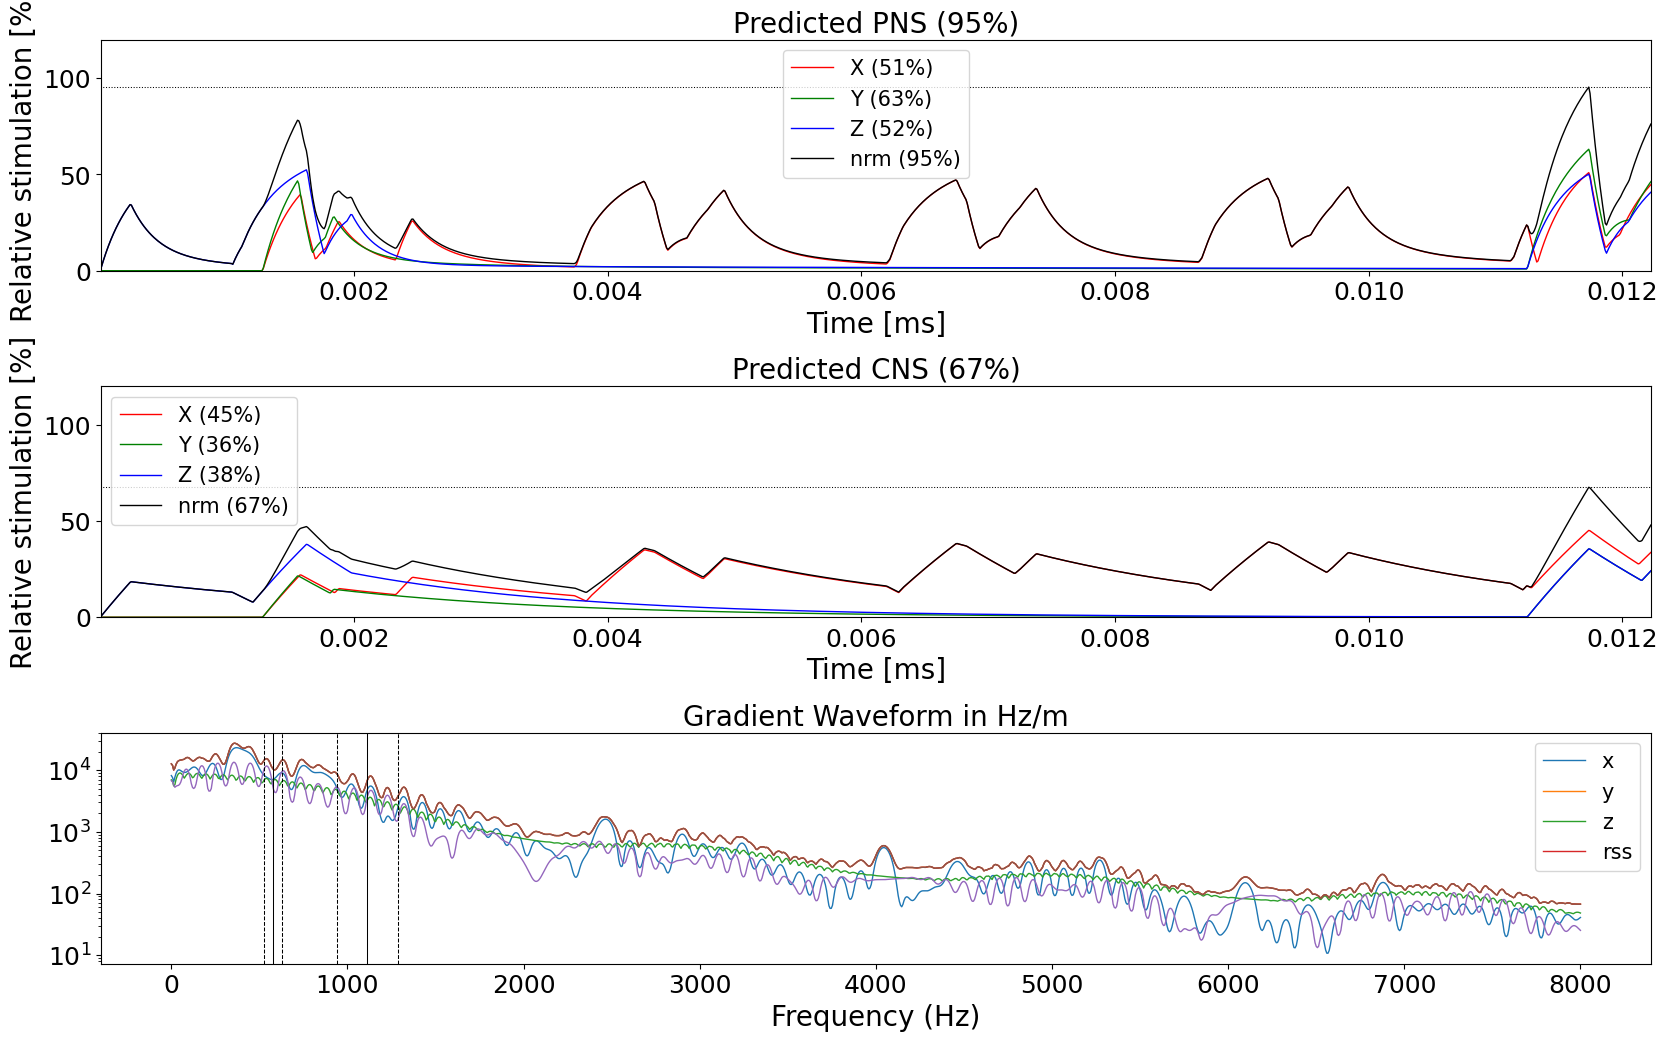

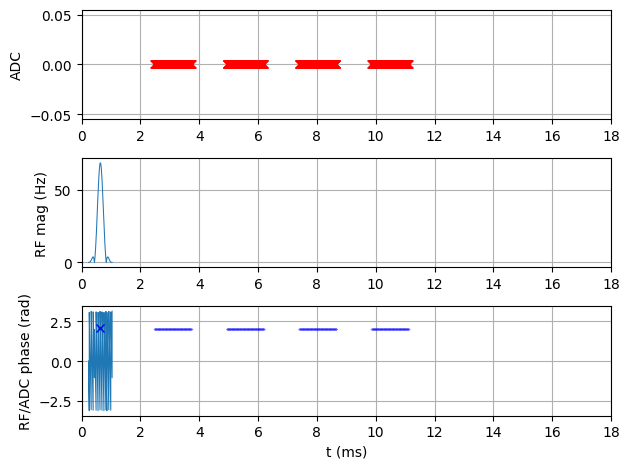

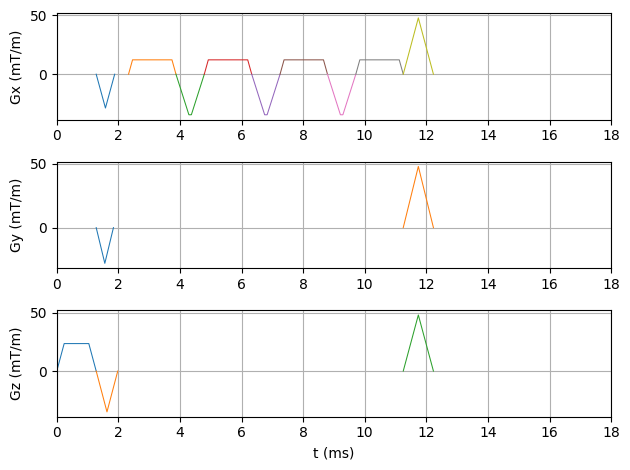

In [51]:
meflash_version = 'v0.9.0-midres'
meflash_out_dir = Path('seq')
meflash_out_dir.mkdir(parents=True, exist_ok=True)
meflash_name = (
    f'meflash_fov{int(fov*1e3)}_'
    f'mat{nx}x{ny}_slc{n_slices}_thk{int(slice_thickness*1e3)}_'
    f'echo{me_timing["n_echoes"]}_{meflash_version}.seq'
 )
meflash_path = meflash_out_dir / meflash_name
# seq_meflash.seq.write(str(meflash_path))
print(f'Wrote ME-FLASH sequence: {meflash_path}')

seq_meflash.check_safety_lims(r'E:\MGH\Healthy_Grad\asc\CimaX.asc', time_range=[0, 21e-3], cns=True, do_plot=True)
seq_meflash.seq.plot(time_disp='ms', grad_disp='mT/m', time_range=[0, 18e-3])

## Twix-Based Spiral NUFFT Reconstruction

This section reconstructs the acquired spiral diffusion Twix data with SigPy NUFFT-SENSE.

Pipeline:
1. Load meflash Twix and estimate slice-wise ESPIRiT coil sensitivity maps.
2. Load spiral diffusion Twix and reorder into canonical `(rep, slc, dir, shot, ch, ro)`.
3. Build NUFFT coordinates from the designed spiral trajectory interleaves.
4. Run direct SENSE reconstruction for each `(rep, slc, dir)`.

In [52]:
from tqdm.auto import tqdm
from scipy.fft import fftshift, ifftshift, ifft2
import sigpy as sp
from sigpy.mri.app import EspiritCalib
from twixtools import read_twix, map_twix


def _ifftc2_local(ksp):
    return fftshift(ifft2(ifftshift(ksp, axes=(-2, -1)), axes=(-2, -1), norm='ortho'), axes=(-2, -1))


def _safe_get_twix_image_obj(mapped_obj):
    if isinstance(mapped_obj, list) and len(mapped_obj) > 0:
        mapped_obj = mapped_obj[-1]
    if isinstance(mapped_obj, dict) and 'image' in mapped_obj:
        return mapped_obj['image']
    raise RuntimeError('Mapped twix object does not contain a readable image block.')


def _infer_axes_from_twix_dims(img_obj, raw_shape, role_candidates, role_expected_sizes=None):
    dims = tuple(getattr(img_obj, 'dims', ()))
    full_shape = tuple(getattr(img_obj, 'shape', ()))
    if len(dims) == 0 or len(full_shape) != len(dims):
        return None

    # Prefer unsqueezed arrays. Keep a legacy path for already-squeezed arrays.
    if len(raw_shape) == len(dims):
        dim_labels = list(dims)
    else:
        non_singleton_dims = [d for d, s in zip(dims, full_shape) if int(s) > 1]
        if len(raw_shape) != len(non_singleton_dims):
            return None
        dim_labels = non_singleton_dims

    dim_to_axes = {}
    for axis, dim_name in enumerate(dim_labels):
        dim_to_axes.setdefault(dim_name, []).append(axis)

    axis_map = {}
    used_axes = set()
    for role, candidates in role_candidates.items():
        role_axes = []
        for d in candidates:
            role_axes.extend([ax for ax in dim_to_axes.get(d, []) if ax not in used_axes])

        if len(role_axes) == 0:
            return None

        hit = None
        if role_expected_sizes is not None and role in role_expected_sizes and role_expected_sizes[role] is not None:
            target_size = int(role_expected_sizes[role])
            size_matches = [ax for ax in role_axes if int(raw_shape[ax]) == target_size]
            if len(size_matches) == 1:
                hit = size_matches[0]
            elif len(size_matches) > 1:
                # Prefer non-singleton axis when expected size appears multiple times.
                non_single = [ax for ax in size_matches if int(raw_shape[ax]) > 1]
                hit = non_single[0] if len(non_single) > 0 else size_matches[0]

        if hit is None:
            hit = role_axes[0]

        axis_map[role] = hit
        used_axes.add(hit)
    return axis_map


def _infer_axis_map_first_dims(shape, expected):
    axis_map = {}
    used = set()
    for key, size in expected.items():
        if size is None:
            continue
        matches = [i for i, s in enumerate(shape) if int(s) == int(size) and i not in used]
        if len(matches) == 1:
            axis_map[key] = matches[0]
            used.add(matches[0])
    return axis_map


def _extract_roles_from_raw(raw, axis_map, ordered_roles, context_name='twix'):
    axes = [int(axis_map[r]) for r in ordered_roles]
    if len(set(axes)) != len(axes):
        raise RuntimeError(f'{context_name}: duplicate axes in role map: {axis_map}')

    arr = np.moveaxis(raw, axes, np.arange(len(ordered_roles)))
    extra_shape = arr.shape[len(ordered_roles):]

    # Any unmapped dimensions must be singleton so they can be safely dropped.
    if any(int(s) != 1 for s in extra_shape):
        raise RuntimeError(
            f'{context_name}: found unmapped non-singleton axes {extra_shape}; '
            f'axis_map={axis_map}, raw_shape={raw.shape}'
        )

    if len(extra_shape) > 0:
        arr = arr.reshape(arr.shape[:len(ordered_roles)])

    return arr


def _center_crop_or_pad_2d(arr, target_y, target_x):
    out = np.zeros(arr.shape[:-2] + (target_y, target_x), dtype=arr.dtype)
    src_y, src_x = arr.shape[-2], arr.shape[-1]

    copy_y = min(src_y, target_y)
    copy_x = min(src_x, target_x)

    src_y0 = (src_y - copy_y) // 2
    src_x0 = (src_x - copy_x) // 2
    dst_y0 = (target_y - copy_y) // 2
    dst_x0 = (target_x - copy_x) // 2

    out[..., dst_y0:dst_y0 + copy_y, dst_x0:dst_x0 + copy_x] = arr[..., src_y0:src_y0 + copy_y, src_x0:src_x0 + copy_x]
    return out


# Try GPU first; if unavailable, use CPU.
try:
    _sp_device = sp.Device(0)
    _ = _sp_device.xp.zeros(1)
except Exception:
    _sp_device = sp.Device(-1)

print('SigPy reconstruction device:', _sp_device)

SigPy reconstruction device: <CUDA Device 0>


In [53]:
# b0_path = Path('scan_data/meas_MID00243_FID16403_meflash_fov200_mat160_slc3_thk5_echo4_v0_2_0.dat')
# b0_path = Path('scan_data/meas_MID00374_FID16534_meflash_fov200_mat256_slc3_thk5_echo4_v0_3_0_highres.dat')
# b0_path = Path('scan_data/meas_MID00389_FID16549_meflash_fov200_mat256x256_slc3_thk5_echo4_v0_3_2_highres.dat') # Manoe's phantom
# b0_path = Path('scan_data/meas_MID00231_FID16931_meflash_fov200_mat256x256_slc3_thk5_echo4_v0_3_3_highres.dat')
# b0_path = Path('scan_data/meas_MID00274_FID16974_meflash_fov200_mat256x256_slc3_thk5_echo4_v0_3_3_highres.dat')
# b0_path = Path(r'scan_data\2026_0423_ACDC\meas_MID00495_FID17203_meflash_fov210_mat256x256_slc3_thk5_echo4_v0_4_0_highres.dat')
# b0_path = Path(r'scan_data\2026_0423_RedHead\meas_MID00536_FID17243_meflash_fov210_mat256x256_slc3_thk5_echo4_v0_4_0_highres.dat')
b0_path = Path(r'scan_data\2026_0425_Bay2\meas_MID00049_FID25431_meflash_fov210_mat140_slc3_thk5_echo4_v0_9_0.dat')


# spiral_path = Path('scan_data/meas_MID00240_FID16400_fs_se_dti_spiral_vds_b2000_dir7_shot16_slice3_acc8_v0_4_1.dat')
# spiral_path = Path('scan_data/meas_MID00249_FID16409_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc8_v0_5_0.dat')
# spiral_path = Path('scan_data/meas_MID00253_FID16413_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc1_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00254_FID16414_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc1_5_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00252_FID16412_fs_se_dti_spiral_vds_b8000_dir7_shot16_slc3_acc2_v0_6_0.dat')
# spiral_path = Path('scan_data/meas_MID00388_FID16548_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_v0_7_2_highres.dat') # Manoe's phantom
# spiral_path = Path('scan_data/meas_MID00229_FID16929_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_7_2_skope.dat') # 
# spiral_path = Path('scan_data/meas_MID00230_FID16930_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat') # 
# spiral_path = Path('scan_data/meas_MID00232_FID16932_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat') # 
# spiral_path = Path('scan_data/meas_MID00242_FID16942_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat') # 
# spiral_path = Path('scan_data/meas_MID00275_FID16975_fs_se_dti_spiral_vds_b10000_dir7_shot40_slc3_acc1_0_v0_7_3_skop.dat')
# spiral_path = Path('scan_data/meas_MID00276_FID16976_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_7_2_skope.dat')

# spiral_path = Path(r'scan_data\2026_0423\meas_MID00501_FID17209_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_2_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00502_FID17210_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_3_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00503_FID17211_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_4_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00505_FID17213_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_5_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423\meas_MID00507_FID17215_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_6_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423_ACDC\meas_MID00514_FID17222_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_7_skope.dat')
# spiral_path = Path(r'scan_data\2026_0423_RedHead\meas_MID00537_FID17244_fs_se_dti_spiral_vds_b2000_dir7_shot40_slc3_acc1_0_v0_8_7_skope.dat')

# spiral_path = Path(r'scan_data\2026_0423_RedHead\meas_MID00538_FID17245_fs_se_dti_spiral_vds_b200_dir7_shot40_slc3_acc1_0_v0_8_7_skope.dat')

spiral_path = Path(r'scan_data\2026_0425_Bay2\meas_MID00055_FID25437_fs_se_dti_spiral_vds_b2000_dir7_shot3_slice3_acc1_0_v0_9_0.dat')

In [54]:
# ------------------------------------------------------------------
# Step 1: Load meflash Twix and estimate ESPIRiT sensitivity maps
# ------------------------------------------------------------------
if not b0_path.exists():
    raise FileNotFoundError(f'Could not find b0 Twix file: {b0_path}')

b0_twix_raw = read_twix(str(b0_path), parse_pmu=False)
b0_twix_mapped = map_twix(b0_twix_raw)
b0_img_obj = _safe_get_twix_image_obj(b0_twix_mapped)
b0_raw = np.asarray(b0_img_obj[:])
print('Raw b0 image shape:', b0_raw.shape)

b0_axis_map = _infer_axes_from_twix_dims(
    b0_img_obj,
    b0_raw.shape,
    role_candidates={
        'slc': ('Sli', 'Set'),
        'echo': ('Eco',),
        'ky': ('Lin',),
        'ch': ('Cha',),
        'kx': ('Col',),
    },
)

if b0_axis_map is not None:
    print('B0 axis map from TWIX header dims:', b0_axis_map)
    b0_ksp = _extract_roles_from_raw(
        b0_raw,
        b0_axis_map,
        ordered_roles=('slc', 'echo', 'ky', 'ch', 'kx'),
        context_name='b0',
    ).astype(np.complex64, copy=False)
else:
    # Fallback: assume (slc, echo, ky, ch, kx) or (echo, slc, ky, ch, kx)
    if b0_raw.ndim != 5:
        raise RuntimeError(f'Expected 5D b0 data, got shape {b0_raw.shape}')
    if b0_raw.shape[0] == n_slices:
        slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = 0, 1, 2, 3, 4
    elif b0_raw.shape[1] == n_slices:
        slc_axis, echo_axis, ky_axis, ch_axis, kx_axis = 1, 0, 2, 3, 4
    else:
        raise RuntimeError('Could not infer b0 axes. Please inspect TWIX dimensions.')

    perm_b0 = [slc_axis, echo_axis, ky_axis, ch_axis, kx_axis]
    b0_ksp = np.transpose(b0_raw, perm_b0).astype(np.complex64, copy=False)

print('Canonical b0 k-space shape (slc, echo, ky, ch, kx):', b0_ksp.shape)

# FFT-friendly order: (slc, echo, ch, ky, kx)
b0_ksp = np.transpose(b0_ksp, (0, 1, 3, 2, 4))
# window = np.outer(np.hanning(b0_ksp.shape[-2]), np.hanning(b0_ksp.shape[-1]))
b0_img_coils = _ifftc2_local(b0_ksp)

n_slc_b0, n_echo_b0, n_ch_b0, n_ky_b0, n_kx_b0 = b0_img_coils.shape
sens_maps = np.zeros((n_slc_b0, n_ch_b0, n_ky_b0, n_kx_b0), dtype=np.complex64)

for slc in tqdm(range(n_slc_b0), desc='ESPIRiT', leave=False):
    ksp_ref = b0_ksp[slc, 0]  # (ch, ky, kx)
    sens_est = EspiritCalib(
        ksp_ref,
        calib_width=36,
        kernel_width=16,
        # crop=0.95,
        crop=0,
        thresh=0.02,
        device=_sp_device,
        show_pbar=False,
    ).run()

    if hasattr(sens_est, 'get'):
        sens_est = sens_est.get()
    sens_maps[slc] = np.asarray(sens_est, dtype=np.complex64)

print('Sensitivity map shape (slc, ch, y, x):', sens_maps.shape)

Software version: VD/VE (!?)

Scan  0


100%|██████████| 59.0M/59.0M [00:00<00:00, 1.24GB/s]

Scan  1



100%|██████████| 59.8M/59.8M [00:00<00:00, 293MB/s]


Raw b0 image shape: (1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 3, 1, 140, 32, 140)
B0 axis map from TWIX header dims: {'slc': 11, 'echo': 9, 'ky': 13, 'ch': 14, 'kx': 15}
Canonical b0 k-space shape (slc, echo, ky, ch, kx): (3, 4, 140, 32, 140)


ESPIRiT:   0%|          | 0/3 [00:00<?, ?it/s]

Sensitivity map shape (slc, ch, y, x): (3, 32, 140, 140)


Coil-combined b0 image shape (slc, echo, y, x): (3, 4, 140, 140)


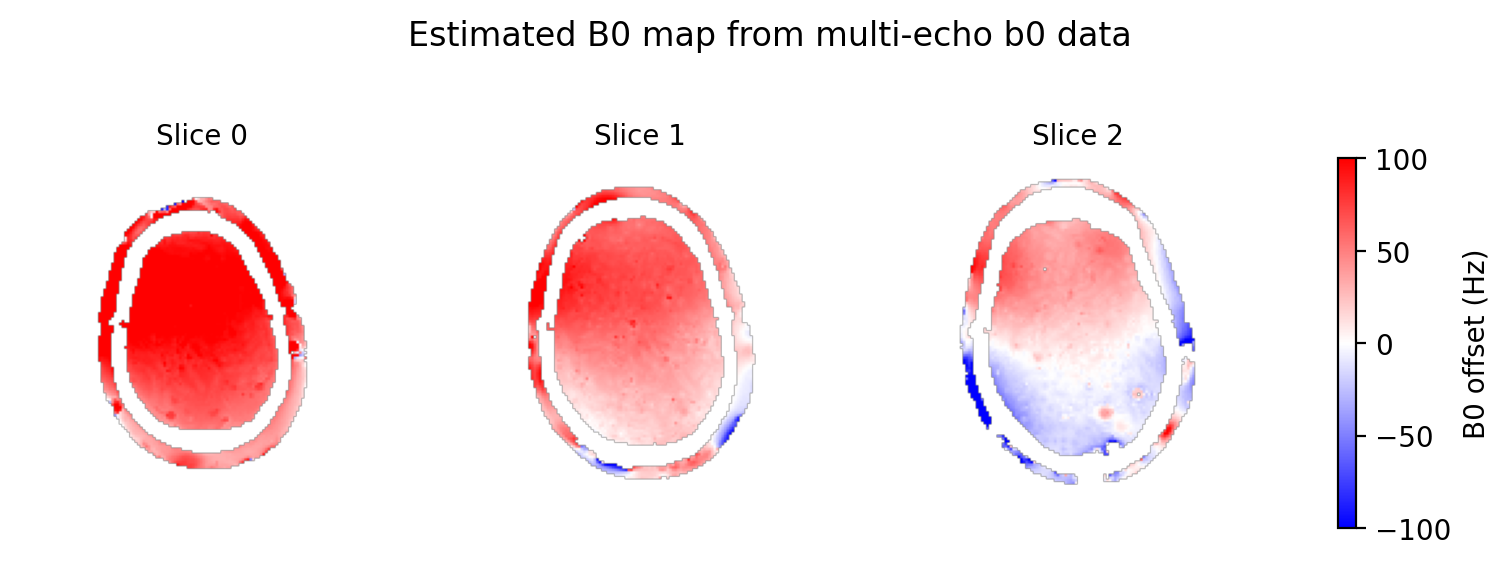

In [56]:
# Coil combine all echoes with sensitivity maps.
den = np.sum(np.abs(sens_maps) ** 2, axis=1) + 1e-8  # (slc, y, x)
num = np.sum(np.conj(sens_maps[:, None, ...]) * b0_img_coils, axis=2)  # (slc, echo, y, x)
b0_img_comb = num / den[:, None, ...]
print('Coil-combined b0 image shape (slc, echo, y, x):', b0_img_comb.shape)

from skimage.restoration import unwrap_phase

# B0 map from linear phase slope over echoes: phi(TE) = phi0 + 2*pi*df*TE
phase_rel = np.angle(b0_img_comb * np.conj(b0_img_comb[:, :1, :, :]))
phase_unw = np.unwrap(phase_rel, axis=1)

te_s = me_timing['te1'] + np.arange(n_echo_b0) * me_timing['echo_spacing']
te_center = te_s - np.mean(te_s)
den_te = np.sum(te_center ** 2) + 1e-12
slope = np.sum(phase_unw * te_center[None, :, None, None], axis=1) / den_te  # rad/s
b0_hz = slope / (2 * np.pi)

# Mask unreliable voxels (low SNR).
mag1 = np.abs(b0_img_comb[:, 0])
mask = mag1 > (0.10 * np.max(mag1, axis=(-2, -1), keepdims=True))
b0_hz_masked = np.where(mask, b0_hz, np.nan)

# Plot B0 map
fig, axes = plt.subplots(1, n_slc_b0, figsize=(10, 4), squeeze=False, dpi=200)
for s in range(n_slc_b0):
    ax = axes[0, s]
    im = ax.imshow(b0_hz_masked[s], cmap='bwr', vmin=-100, vmax=100)
    ax.set_title(f'Slice {s}', fontsize=10)
    ax.axis('off')
fig.suptitle('Estimated B0 map from multi-echo b0 data', fontsize=12, y=0.9)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='B0 offset (Hz)')

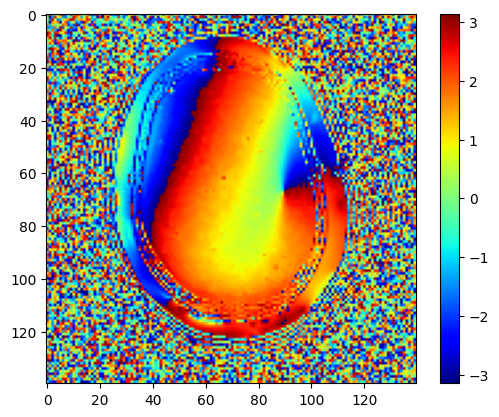

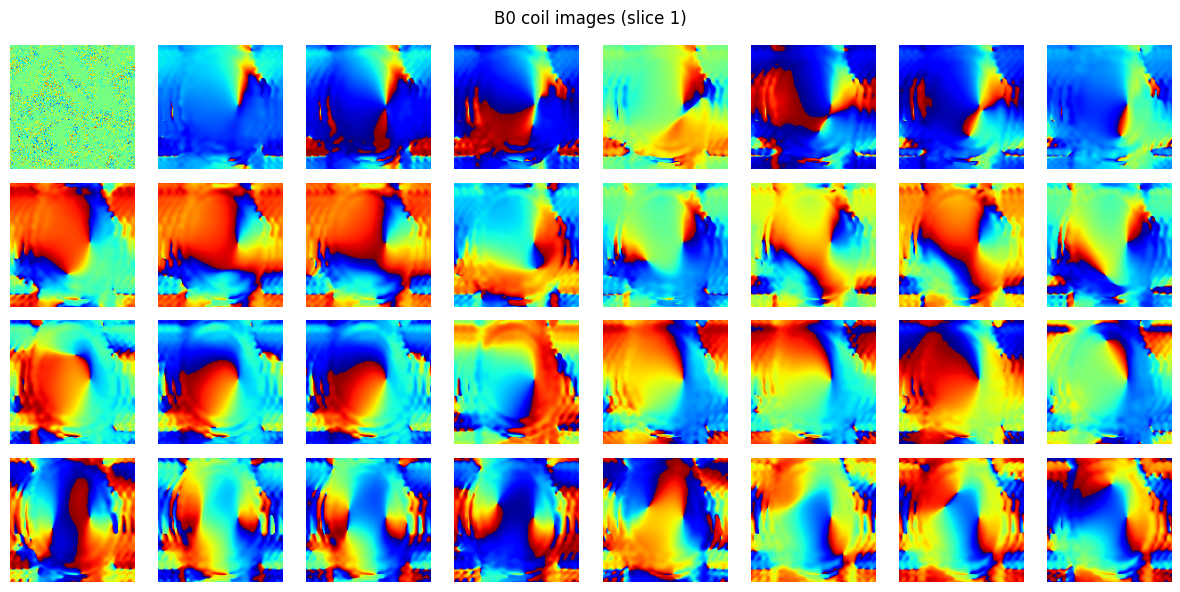

In [57]:
# plt.imshow(np.abs(b0_img_comb[1, 0]), cmap='gray')
plt.imshow(np.angle(b0_img_comb[1, 0]), cmap='jet')
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 6))
for i in range(1, n_ch_b0 + 1):
    plt.subplot(4, 8, i)
    plt.imshow(np.angle(sens_maps[1, i-1]), cmap='jet')
    plt.axis('off')
plt.suptitle('B0 coil images (slice 1)', fontsize=12)
plt.tight_layout()

In [59]:
# ------------------------------------------------------------------
# Step 2: Load spiral diffusion Twix and reorder to canonical shape
# ------------------------------------------------------------------
if not spiral_path.exists():
    raise FileNotFoundError(f'Could not find spiral Twix file: {spiral_path}')

sp_twix_raw = read_twix(str(spiral_path), parse_pmu=False)
sp_twix_mapped = map_twix(sp_twix_raw)
sp_img_obj = _safe_get_twix_image_obj(sp_twix_mapped)
sp_raw = np.asarray(sp_img_obj[:])
print('Raw spiral image shape:', sp_raw.shape)

if sp_raw.ndim < 6:
    raise RuntimeError(f'Expected spiral data with at least 6 dims, got shape {sp_raw.shape}')

sp_axis_map = _infer_axes_from_twix_dims(
    sp_img_obj,
    sp_raw.shape,
    role_candidates={
        'rep': ('Rep',),
        'slc': ('Sli', 'Set'),
        'dir': ('Seg', 'Phs', 'Par'),
        'shot': ('Lin', 'Ave'),
        'ch': ('Cha',),
        'ro': ('Col',),
    },
    role_expected_sizes={
        'rep': int(num_repeats),
        'slc': int(n_slices),
        'dir': int(num_dirs),
        'shot': int(n_shots),
    },
)

if sp_axis_map is not None:
    sp_data = _extract_roles_from_raw(
        sp_raw,
        sp_axis_map,
        ordered_roles=('rep', 'slc', 'dir', 'shot', 'ch', 'ro'),
        context_name='spiral',
    )
    print('Spiral axis map from TWIX header dims:', sp_axis_map)
else:
    expected = {
        'rep': int(num_repeats),
        'slc': int(n_slices),
        'dir': int(num_dirs),
        'shot': int(n_shots),
    }
    axis_guess = _infer_axis_map_first_dims(sp_raw.shape, expected)
    if len(axis_guess) != 4:
        raise RuntimeError(
            'Could not infer spiral data axes from shape. Please inspect TWIX dimensions and update mapping.'
        )

    remaining = [i for i in range(sp_raw.ndim) if i not in axis_guess.values() and int(sp_raw.shape[i]) > 1]
    if len(remaining) < 2:
        raise RuntimeError(
            'Could not infer channel/readout axes from spiral shape. '
            f'shape={sp_raw.shape}, partial_map={axis_guess}'
        )

    # Heuristic fallback: readout axis is typically the longest remaining one.
    ro_axis = max(remaining, key=lambda i: int(sp_raw.shape[i]))
    ch_candidates = [i for i in remaining if i != ro_axis]
    ch_axis = min(ch_candidates, key=lambda i: int(sp_raw.shape[i]))

    axis_guess['ch'] = int(ch_axis)
    axis_guess['ro'] = int(ro_axis)

    sp_data = _extract_roles_from_raw(
        sp_raw,
        axis_guess,
        ordered_roles=('rep', 'slc', 'dir', 'shot', 'ch', 'ro'),
        context_name='spiral',
    )
    print('Spiral axis map from shape heuristic:', axis_guess)

n_rep, n_slc, n_dir, n_shot, n_ch, n_ro = sp_data.shape
print('Canonical spiral data shape (rep, slc, dir, shot, ch, ro):', sp_data.shape)

if n_shot != n_shots:
    print(f'Warning: TWIX shot dimension ({n_shot}) != planned n_shots ({n_shots}). Using min of both.')
if n_dir != num_dirs:
    print(f'Warning: TWIX dir dimension ({n_dir}) != planned num_dirs ({num_dirs}). Using min of both.')

Software version: VD/VE (!?)

Scan  0


100%|██████████| 59.0M/59.0M [00:00<00:00, 1.07GB/s]


Scan  1


100%|██████████| 431M/431M [00:00<00:00, 4.35GB/s]


Raw spiral image shape: (1, 1, 1, 1, 1, 7, 1, 1, 1, 1, 1, 3, 3, 1, 32, 27928)
Spiral axis map from TWIX header dims: {'rep': 7, 'slc': 11, 'dir': 5, 'shot': 12, 'ch': 14, 'ro': 15}
Canonical spiral data shape (rep, slc, dir, shot, ch, ro): (1, 3, 7, 3, 32, 27928)


In [86]:
# ------------------------------------------------------------------
# Step 3: Build NUFFT coordinates from designed spiral interleaves
# ------------------------------------------------------------------
recon_ny = int(ny)
recon_nx = int(nx)

n_shot_use = min(int(n_shots), int(n_shot))
n_dir_use = min(int(num_dirs), int(n_dir))

traj_by_shot = []
for shot_idx in range(n_shot_use):
    k_shot = np.asarray(spiral_vds.get_adc_ktraj(interleaf=shot_idx))
    if k_shot.size == 0:
        raise RuntimeError(f'Empty trajectory for shot {shot_idx}')
    traj_by_shot.append(k_shot)

# Match trajectory length with measured RO samples.
n_ro_design = min([len(k) for k in traj_by_shot])
n_ro_use = min(int(n_ro), int(n_ro_design))
if n_ro_use < 16:
    raise RuntimeError('Too few readout samples after matching trajectory/data lengths.')

traj_by_shot = [k[:n_ro_use] for k in traj_by_shot]

# Normalize to SigPy coordinate convention [-N/2, N/2].
kx_all = np.concatenate([np.real(k) for k in traj_by_shot])
ky_all = np.concatenate([np.imag(k) for k in traj_by_shot])
kmax_x = max(float(np.max(np.abs(kx_all))), 1e-9)
kmax_y = max(float(np.max(np.abs(ky_all))), 1e-9)

coords_by_shot = []
for k in traj_by_shot:
    coord_y = (np.imag(k) / kmax_y) * (recon_ny / 2.0)
    coord_x = (np.real(k) / kmax_x) * (recon_nx / 2.0)
    coords_by_shot.append(np.stack((coord_y, coord_x), axis=-1).astype(np.float32))

print('Reconstruction matrix:', (recon_ny, recon_nx))
print('Using shots:', n_shot_use, 'Using dirs:', n_dir_use)
print('RO samples used per shot:', n_ro_use)
print('Total NUFFT samples per image:', n_shot_use * n_ro_use)

Reconstruction matrix: (140, 140)
Using shots: 3 Using dirs: 7
RO samples used per shot: 27928
Total NUFFT samples per image: 83784


In [87]:
# ------------------------------------------------------------------
# Step 4: Direct SigPy NUFFT-SENSE reconstruction
# ------------------------------------------------------------------
img_sense_spiral = np.zeros((n_rep, n_slc, n_dir_use, recon_ny, recon_nx), dtype=np.complex64)

# Ensure sensitivity map resolution matches target reconstruction matrix.
sens_use = np.asarray(sens_maps, dtype=np.complex64)
if sens_use.shape[-2:] != (recon_ny, recon_nx):
    sens_use = _center_crop_or_pad_2d(sens_use, recon_ny, recon_nx)

if sens_use.shape[0] != n_slc:
    raise RuntimeError(f'Slice mismatch between sensitivities ({sens_use.shape[0]}) and spiral data ({n_slc}).')
if sens_use.shape[1] != n_ch:
    raise RuntimeError(f'Channel mismatch between sensitivities ({sens_use.shape[1]}) and spiral data ({n_ch}).')

total_items = n_rep * n_slc * n_dir_use
print('Starting NUFFT reconstruction ...')
with tqdm(total=total_items, desc='Spiral NUFFT Recon', leave=False) as pbar:
    for rep_idx in range(n_rep):
        for slc_idx in range(n_slc):
            mps_gpu = sp.to_device(sens_use[slc_idx], _sp_device)

            for dir_idx in range(n_dir_use):
                # data shape per frame: (shot, ch, ro)
                d_frame = np.asarray(sp_data[rep_idx, slc_idx, dir_idx, :n_shot_use, :, :n_ro_use], dtype=np.complex64)

                # Concatenate shots into one non-Cartesian acquisition.
                y_cat = np.concatenate([d_frame[s] for s in range(n_shot_use)], axis=-1)  # (ch, pts)
                coord_cat = np.concatenate([coords_by_shot[s] for s in range(n_shot_use)], axis=0)  # (pts, 2)

                y_gpu = sp.to_device(y_cat, _sp_device)
                coord_gpu = sp.to_device(coord_cat, _sp_device)

                dcf_gpu = sp.mri.dcf.pipe_menon_dcf(
                    coord_gpu,
                    img_shape=(recon_ny, recon_nx),
                    max_iter=15,
                    show_pbar=False,
                    device=_sp_device,
                )

                # app = sp.mri.app.L1WaveletRecon(
                # app = sp.mri.app.TotalVariationRecon(
                #     y=y_gpu,
                #     mps=mps_gpu,
                #     coord=coord_gpu,
                #     weights=dcf_gpu,
                #     max_iter=50,
                #     lamda=2e-18,
                #     # lamda=2e-17,
                #     solver="PrimalDualHybridGradient",
                #     device=_sp_device,
                #     show_pbar=False,
                # )

                app = sp.mri.app.SenseRecon(
                    y=y_gpu,
                    mps=mps_gpu,
                    coord=coord_gpu,
                    weights=dcf_gpu,
                    max_iter=50,
                    lamda=1e-3,
                    solver="PrimalDualHybridGradient",
                    device=_sp_device,
                    show_pbar=False,
                )

                recon_gpu = app.run()
                img_sense_spiral[rep_idx, slc_idx, dir_idx] = np.asarray(sp.to_device(recon_gpu, sp.Device(-1)), dtype=np.complex64)
                pbar.update(1)

print('Reconstruction done. Image shape:', img_sense_spiral.shape)

Starting NUFFT reconstruction ...


Spiral NUFFT Recon:   0%|          | 0/21 [00:00<?, ?it/s]

Reconstruction done. Image shape: (1, 3, 7, 140, 140)


In [89]:
# ------------------------------------------------------------------
# Step 5: Interactive visualization (rep/slice/dwi, optimized)
# ------------------------------------------------------------------
import io
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

img_vis = np.asarray(img_sense_spiral)  # (rep, slc, dir, y, x)
if img_vis.ndim != 5:
    raise RuntimeError(f"Expected img_sense_spiral with 5 dims (rep, slc, dir, y, x), got {img_vis.shape}")

n_rep_vis, n_slc_vis, n_dir_vis = img_vis.shape[:3]

# Precompute display orientation once to avoid repeated transposes while sliding.
img_vis_disp = np.transpose(img_vis, (0, 1, 2, 4, 3))  # (rep, slc, dir, x, y)
mag_vis = np.abs(img_vis_disp).astype(np.float32, copy=False)
phs_vis = np.angle(img_vis_disp).astype(np.float32, copy=False)

# Use one global magnitude scale to prevent brightness pumping.
mag_vmax = float(np.percentile(mag_vis, 99.5))
if not np.isfinite(mag_vmax) or mag_vmax <= 0:
    mag_vmax = 1.0

rep_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_rep_vis - 1),
    step=1,
    description='show_rep',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

slc_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_slc_vis - 1),
    step=1,
    description='show_slc',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

dwi_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, n_dir_vis - 1),
    step=1,
    description='show_dwi',
    continuous_update=True,
    readout=True,
    style={'description_width': 'initial'},
)

ui = widgets.HBox([rep_slider, slc_slider, dwi_slider])


def _array_to_png_bytes(arr, vmin, vmax, cmap):
    arr = np.asarray(arr, dtype=np.float32)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
        vmin, vmax = 0.0, 1.0
    norm = np.clip((arr - vmin) / (vmax - vmin), 0.0, 1.0)
    rgba = (cmap(norm) * 255).astype(np.uint8)
    img = Image.fromarray(rgba, mode='RGBA')
    buf = io.BytesIO()
    img.save(buf, format='PNG', optimize=False, compress_level=1)
    return buf.getvalue()


# Pre-render all frames once so slider updates only swap PNG buffers.
print('Pre-rendering display frames for smooth interaction ...')
gray_cmap = plt.get_cmap('gray')
jet_cmap = plt.get_cmap('jet')

mag_png = np.empty((n_rep_vis, n_slc_vis, n_dir_vis), dtype=object)
phs_png = np.empty((n_rep_vis, n_slc_vis, n_dir_vis), dtype=object)

for rep_idx in range(n_rep_vis):
    for slc_idx in range(n_slc_vis):
        for dir_idx in range(n_dir_vis):
            mag_vmax = float(np.percentile(mag_vis[rep_idx, slc_idx, dir_idx], 99.5))
            mag_png[rep_idx, slc_idx, dir_idx] = _array_to_png_bytes(
                mag_vis[rep_idx, slc_idx, dir_idx].T,
                0.0,
                mag_vmax,
                gray_cmap,
            )
            phs_png[rep_idx, slc_idx, dir_idx] = _array_to_png_bytes(
                phs_vis[rep_idx, slc_idx, dir_idx].T,
                -np.pi,
                np.pi,
                jet_cmap,
            )

print('Pre-render complete.')

title_mag = widgets.HTML()
title_phs = widgets.HTML()
mag_widget = widgets.Image(format='png', layout=widgets.Layout(width='500px', height='500px'))
phs_widget = widgets.Image(format='png', layout=widgets.Layout(width='500px', height='500px'))

view = widgets.HBox([
    widgets.VBox([title_mag, mag_widget]),
    widgets.VBox([title_phs, phs_widget]),
])


def _update_widget_images(_=None):
    show_rep = int(rep_slider.value)
    show_slc = int(slc_slider.value)
    show_dwi = int(dwi_slider.value)

    mag_widget.value = mag_png[show_rep, show_slc, show_dwi]
    phs_widget.value = phs_png[show_rep, show_slc, show_dwi]

    title_mag.value = f'<b>Rep {show_rep} | Slice {show_slc} | {dir_labels[show_dwi]} | Magnitude</b>'
    title_phs.value = f'<b>Rep {show_rep} | Slice {show_slc} | {dir_labels[show_dwi]} | Phase</b>'


rep_slider.observe(_update_widget_images, names='value')
slc_slider.observe(_update_widget_images, names='value')
dwi_slider.observe(_update_widget_images, names='value')
_update_widget_images()

display(widgets.VBox([ui, view]))
print('Interactive mode: rep/slice/dwi sliders with pre-rendered images for low-lag browsing.')

Pre-rendering display frames for smooth interaction ...
Pre-render complete.


Interactive mode: rep/slice/dwi sliders with pre-rendered images for low-lag browsing.


In [77]:
class SpiralOffresExactLinop(sp.linop.Linop):
    def __init__(
        self,
        img_shape,
        sens,
        coord,
        field_map_hz,
        sample_time_s,
        device,
        weights_sqrt=None,
        time_batch_size=1024,
    ):
        """
        Exact phase-accumulation MRI operator (no NUFFT segmentation).

        Forward model:
            y_c(t) = sum_r s_c(r) * x(r) * exp(-i * phi(r,t))
            phi(r,t) = 2*pi*df(r)*t + 2*pi*(ky(t)*ry/ny + kx(t)*rx/nx)

        where df is in Hz (so 2*pi*df = gamma*DeltaB0 in rad/s).
        """
        self.device = sp.Device(device)
        self.ny, self.nx = [int(v) for v in img_shape]

        sens = np.asarray(sens, dtype=np.complex64)
        if sens.shape[-2:] != (self.ny, self.nx):
            raise ValueError(f"sens shape mismatch: {sens.shape[-2:]} vs {(self.ny, self.nx)}")

        self.nc = int(sens.shape[0])
        self.npix = int(self.ny * self.nx)

        coord = np.asarray(coord, dtype=np.float32)
        if coord.ndim != 2 or coord.shape[1] != 2:
            raise ValueError(f"coord must be (ns, 2), got {coord.shape}")
        self.ns = int(coord.shape[0])

        t = np.asarray(sample_time_s, dtype=np.float32).reshape(-1)
        if t.shape[0] != self.ns:
            raise ValueError(
                f"sample_time_s length mismatch: {t.shape[0]} vs ns={self.ns}"
            )

        fmap = np.asarray(field_map_hz, dtype=np.float32)
        if fmap.shape != (self.ny, self.nx):
            raise ValueError(
                f"field_map_hz shape mismatch: got {fmap.shape}, expected {(self.ny, self.nx)}"
            )

        self.time_batch_size = max(64, int(time_batch_size))

        self.sens = sp.to_device(sens.reshape(self.nc, self.npix), self.device)
        self.coord = sp.to_device(coord, self.device)
        self.field_map_hz = sp.to_device(fmap.reshape(self.npix), self.device)
        self.time_s = sp.to_device(t, self.device)

        # Spatial index grid centered at k-space origin.
        ry = (np.arange(self.ny, dtype=np.float32) - self.ny / 2.0) / float(self.ny)
        rx = (np.arange(self.nx, dtype=np.float32) - self.nx / 2.0) / float(self.nx)
        gy, gx = np.meshgrid(ry, rx, indexing="ij")
        self.ry = sp.to_device(gy.reshape(self.npix), self.device)
        self.rx = sp.to_device(gx.reshape(self.npix), self.device)

        if weights_sqrt is None:
            self.weights_sqrt = None
        else:
            ws = np.asarray(weights_sqrt, dtype=np.float32).reshape(-1)
            if ws.shape[0] != self.ns:
                raise ValueError(
                    f"weights_sqrt length mismatch: {ws.shape[0]} vs ns={self.ns}"
                )
            self.weights_sqrt = sp.to_device(ws, self.device)

        super().__init__((self.nc, self.ns), (self.ny, self.nx))

    def _phase_block(self, coord_b, time_b):
        xp = self.device.xp

        phi_offres = 2.0 * xp.pi * xp.outer(time_b, self.field_map_hz)
        ky = coord_b[:, 0]
        kx = coord_b[:, 1]
        phi_grad = 2.0 * xp.pi * (
            xp.outer(ky, self.ry) + xp.outer(kx, self.rx)
        )
        return (phi_offres + phi_grad).astype(xp.float32, copy=False)

    def _apply(self, x):
        xp = self.device.xp
        x = sp.to_device(x, self.device).reshape(self.npix).astype(xp.complex64, copy=False)

        y = xp.zeros((self.nc, self.ns), dtype=xp.complex64)

        for t_start in range(0, self.ns, self.time_batch_size):
            t_end = min(t_start + self.time_batch_size, self.ns)

            coord_b = self.coord[t_start:t_end]
            time_b = self.time_s[t_start:t_end]
            phase = self._phase_block(coord_b, time_b)
            E = xp.exp(-1j * phase).astype(xp.complex64, copy=False)

            for c in range(self.nc):
                y[c, t_start:t_end] = E @ (self.sens[c] * x)

        if self.weights_sqrt is not None:
            y = y * self.weights_sqrt[None, :]

        return y

    def _adjoint_linop(self):
        return SpiralOffresExactAdjointLinop(self)


class SpiralOffresExactAdjointLinop(sp.linop.Linop):
    def __init__(self, parent):
        self.parent = parent
        super().__init__(parent.ishape, parent.oshape)

    def _apply(self, y):
        p = self.parent
        xp = p.device.xp
        y = sp.to_device(y, p.device).astype(xp.complex64, copy=False)

        if p.weights_sqrt is not None:
            y = y * p.weights_sqrt[None, :]

        x_acc = xp.zeros(p.npix, dtype=xp.complex64)

        for t_start in range(0, p.ns, p.time_batch_size):
            t_end = min(t_start + p.time_batch_size, p.ns)

            coord_b = p.coord[t_start:t_end]
            time_b = p.time_s[t_start:t_end]
            phase = p._phase_block(coord_b, time_b)
            E_adj = xp.exp(1j * phase).astype(xp.complex64, copy=False)

            for c in range(p.nc):
                x_acc += xp.conj(p.sens[c]) * (E_adj.T @ y[c, t_start:t_end])

        return x_acc.reshape(p.ny, p.nx)

    def _adjoint_linop(self):
        return self.parent


class SpiralOffresExactRecon(sp.app.LinearLeastSquares):
    def __init__(
        self,
        y,
        sens,
        coord,
        field_map_hz,
        sample_time_s,
        lamda=0,
        device=sp.cpu_device,
        weights_sqrt=None,
        time_batch_size=1024,
        show_pbar=True,
        **kwargs,
    ):
        device = sp.Device(device)
        y = sp.to_device(np.asarray(y, dtype=np.complex64), device=device)

        A = SpiralOffresExactLinop(
            img_shape=sens.shape[1:],
            sens=sens,
            coord=coord,
            field_map_hz=field_map_hz,
            sample_time_s=sample_time_s,
            device=device,
            weights_sqrt=weights_sqrt,
            time_batch_size=time_batch_size,
        )

        super().__init__(A, y, lamda=lamda, show_pbar=show_pbar, **kwargs)

In [85]:
# ------------------------------------------------------------------
# Step 4b: Exact off-resonance reconstruction (direct phase accumulation)
# ------------------------------------------------------------------
from scipy.ndimage import gaussian_filter

required = [
    "sp_data", "sens_use", "coords_by_shot", "n_shot_use", "n_ro_use",
    "adc_dwell_s", "recon_ny", "recon_nx", "_sp_device", "b0_hz_masked",
    "img_sense_spiral",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}")


def _prepare_field_map_slice(field_map_all, slc_idx, ny, nx, smooth_sigma=1.0):
    fmap = np.asarray(field_map_all[int(slc_idx)], dtype=np.float32)
    if fmap.shape != (int(ny), int(nx)):
        if "_center_crop_or_pad_2d" not in globals():
            raise RuntimeError(f"Field-map shape mismatch: {fmap.shape} vs {(int(ny), int(nx))}")
        fmap = _center_crop_or_pad_2d(fmap[None, ...], int(ny), int(nx))[0].astype(np.float32)

    finite = np.isfinite(fmap)
    if not np.any(finite):
        return np.zeros((int(ny), int(nx)), dtype=np.float32)

    fill = float(np.nanmedian(fmap[finite]))
    fmap = np.where(finite, fmap, fill).astype(np.float32)

    if float(smooth_sigma) > 0:
        fmap = gaussian_filter(fmap, sigma=float(smooth_sigma)).astype(np.float32)

    fmap -= float(np.median(fmap))
    return fmap


def _sharpness_metric(img):
    mag = np.abs(np.asarray(img, dtype=np.complex64)).astype(np.float32)
    gx, gy = np.gradient(mag)
    return float(np.mean(np.sqrt(gx * gx + gy * gy)))


def _contrast_metric(img):
    mag = np.abs(np.asarray(img, dtype=np.complex64)).astype(np.float32)
    return float(np.percentile(mag, 90) - np.percentile(mag, 10))


def _safe_norm_ratio(num, den, eps=1e-20):
    return float(num) / max(float(den), float(eps))


# Case selection: one representative frame for careful model validation.
offres_rep = int(globals().get("offres_rep", 0))
offres_slc = int(globals().get("offres_slc", 0))
offres_dir = int(globals().get("offres_dir", 0))

coord_nom = np.concatenate(
    [np.asarray(coords_by_shot[s][: int(n_ro_use)], dtype=np.float32) for s in range(int(n_shot_use))],
    axis=0,
).astype(np.float32)

d_frame = np.asarray(
    sp_data[offres_rep, offres_slc, offres_dir, : int(n_shot_use), :, : int(n_ro_use)],
    dtype=np.complex64,
)
y_cat = np.concatenate([d_frame[s] for s in range(int(n_shot_use))], axis=-1).astype(np.complex64)

sample_time_s = np.tile(
    np.arange(int(n_ro_use), dtype=np.float32) * float(adc_dwell_s),
    int(n_shot_use),
).astype(np.float32)

if sample_time_s.shape[0] != coord_nom.shape[0]:
    n = min(sample_time_s.shape[0], coord_nom.shape[0])
    sample_time_s = sample_time_s[:n]
    coord_nom = coord_nom[:n]
    y_cat = y_cat[:, :n]

field_map_hz = _prepare_field_map_slice(
    b0_hz_masked,
    slc_idx=offres_slc,
    ny=int(recon_ny),
    nx=int(recon_nx),
    smooth_sigma=float(globals().get("offres_fmap_smooth_sigma", 1.0)),
)

sens_slc = np.asarray(sens_use[offres_slc], dtype=np.complex64)
if sens_slc.shape[-2:] != (int(recon_ny), int(recon_nx)):
    sens_slc = _center_crop_or_pad_2d(sens_slc, int(recon_ny), int(recon_nx)).astype(np.complex64)

# DCF used as W^(1/2) in weighted least squares.
coord_gpu = sp.to_device(coord_nom, _sp_device)
dcf_gpu = sp.mri.dcf.pipe_menon_dcf(
    coord_gpu,
    img_shape=(int(recon_ny), int(recon_nx)),
    max_iter=15,
    show_pbar=False,
    device=_sp_device,
)
dcf = np.asarray(sp.to_device(dcf_gpu, sp.Device(-1)), dtype=np.float32)
weights_sqrt = np.sqrt(np.maximum(dcf, 1e-8)).astype(np.float32)
y_w = (y_cat * weights_sqrt[None, :]).astype(np.complex64)

# Nominal reconstruction baseline.
baseline_app = sp.mri.app.SenseRecon(
    y=sp.to_device(y_cat, _sp_device),
    mps=sp.to_device(sens_slc, _sp_device),
    coord=coord_gpu,
    weights=sp.to_device(dcf, _sp_device),
    max_iter=35,
    lamda=1e-3,
    solver="PrimalDualHybridGradient",
    device=_sp_device,
    show_pbar=True,
)
img_nominal = np.asarray(sp.to_device(baseline_app.run(), sp.Device(-1)), dtype=np.complex64)

nom_sharp = _sharpness_metric(img_nominal)
nom_contrast = _contrast_metric(img_nominal)

# Compact experiment set to keep runtime tractable with exact matrix operators.
lamda_grid = [1e-7]
max_iter_exact = int(globals().get("offres_exact_max_iter", 8))
results_exact = []

for lam in lamda_grid:
    app_exact = SpiralOffresExactRecon(
        y=y_w,
        sens=sens_slc,
        coord=coord_nom,
        field_map_hz=field_map_hz,
        sample_time_s=sample_time_s,
        lamda=float(lam),
        device=_sp_device,
        weights_sqrt=weights_sqrt,
        time_batch_size=int(globals().get("offres_time_batch_size", 4096)),
        solver="PrimalDualHybridGradient",
        max_iter=max_iter_exact,
        tol=1e-6,
        show_pbar=True,
        x=sp.to_device(img_nominal, _sp_device),
    )

    x_gpu = app_exact.run()
    recon = np.asarray(sp.to_device(x_gpu, sp.Device(-1)), dtype=np.complex64)
    Ax = np.asarray(sp.to_device(app_exact.A * x_gpu, sp.Device(-1)), dtype=np.complex64)

    resid = _safe_norm_ratio(np.linalg.norm((Ax - y_w).ravel()), np.linalg.norm(y_w.ravel()))
    sharp = _sharpness_metric(recon)
    contrast = _contrast_metric(recon)
    score = (sharp / max(nom_sharp, 1e-20)) + 0.30 * (contrast / max(nom_contrast, 1e-20)) - 0.45 * resid

    results_exact.append(
        {
            "lamda": float(lam),
            "img": recon,
            "resid": float(resid),
            "sharp": float(sharp),
            "contrast": float(contrast),
            "score": float(score),
        }
    )

results_exact.sort(key=lambda r: r["score"], reverse=True)
best_exact = results_exact[0]

# Conservative acceptance rule: keep exact model only when it materially improves sharpness.
if best_exact["sharp"] >= 1.02 * nom_sharp:
    img_sense_spiral_offres_case = np.asarray(best_exact["img"], dtype=np.complex64)
    final_tag = "exact off-res accepted"
else:
    img_sense_spiral_offres_case = np.asarray(img_nominal, dtype=np.complex64)
    final_tag = "fallback to nominal"

if "img_sense_spiral_offres" not in globals():
    img_sense_spiral_offres = np.asarray(img_sense_spiral, dtype=np.complex64).copy()
img_sense_spiral_offres[offres_rep, offres_slc, offres_dir] = img_sense_spiral_offres_case

print("Field-map stats [Hz]:", float(np.min(field_map_hz)), float(np.max(field_map_hz)), float(np.std(field_map_hz)))
print("Decision:", final_tag)
print(f"Nominal sharp/contrast: {nom_sharp:.4e} / {nom_contrast:.4e}")
print(
    f"Best exact sharp/contrast/resid: {best_exact['sharp']:.4e} / "
    f"{best_exact['contrast']:.4e} / {best_exact['resid']:.4e} (lamda={best_exact['lamda']:.1e})"
)

mag_nom = np.abs(img_nominal).astype(np.float32)
mag_exact = np.abs(best_exact["img"]).astype(np.float32)
mag_out = np.abs(img_sense_spiral_offres_case).astype(np.float32)

vmax = float(max(np.percentile(mag_nom, 99.5), np.percentile(mag_exact, 99.5), 1e-12))
diff = (mag_out - mag_nom).T
mx = float(np.percentile(np.abs(diff), 99.5))
mx = mx if np.isfinite(mx) and mx > 0 else 1.0


MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

SenseRecon:   0%|          | 0/35 [00:00<?, ?it/s]

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

KeyboardInterrupt: 

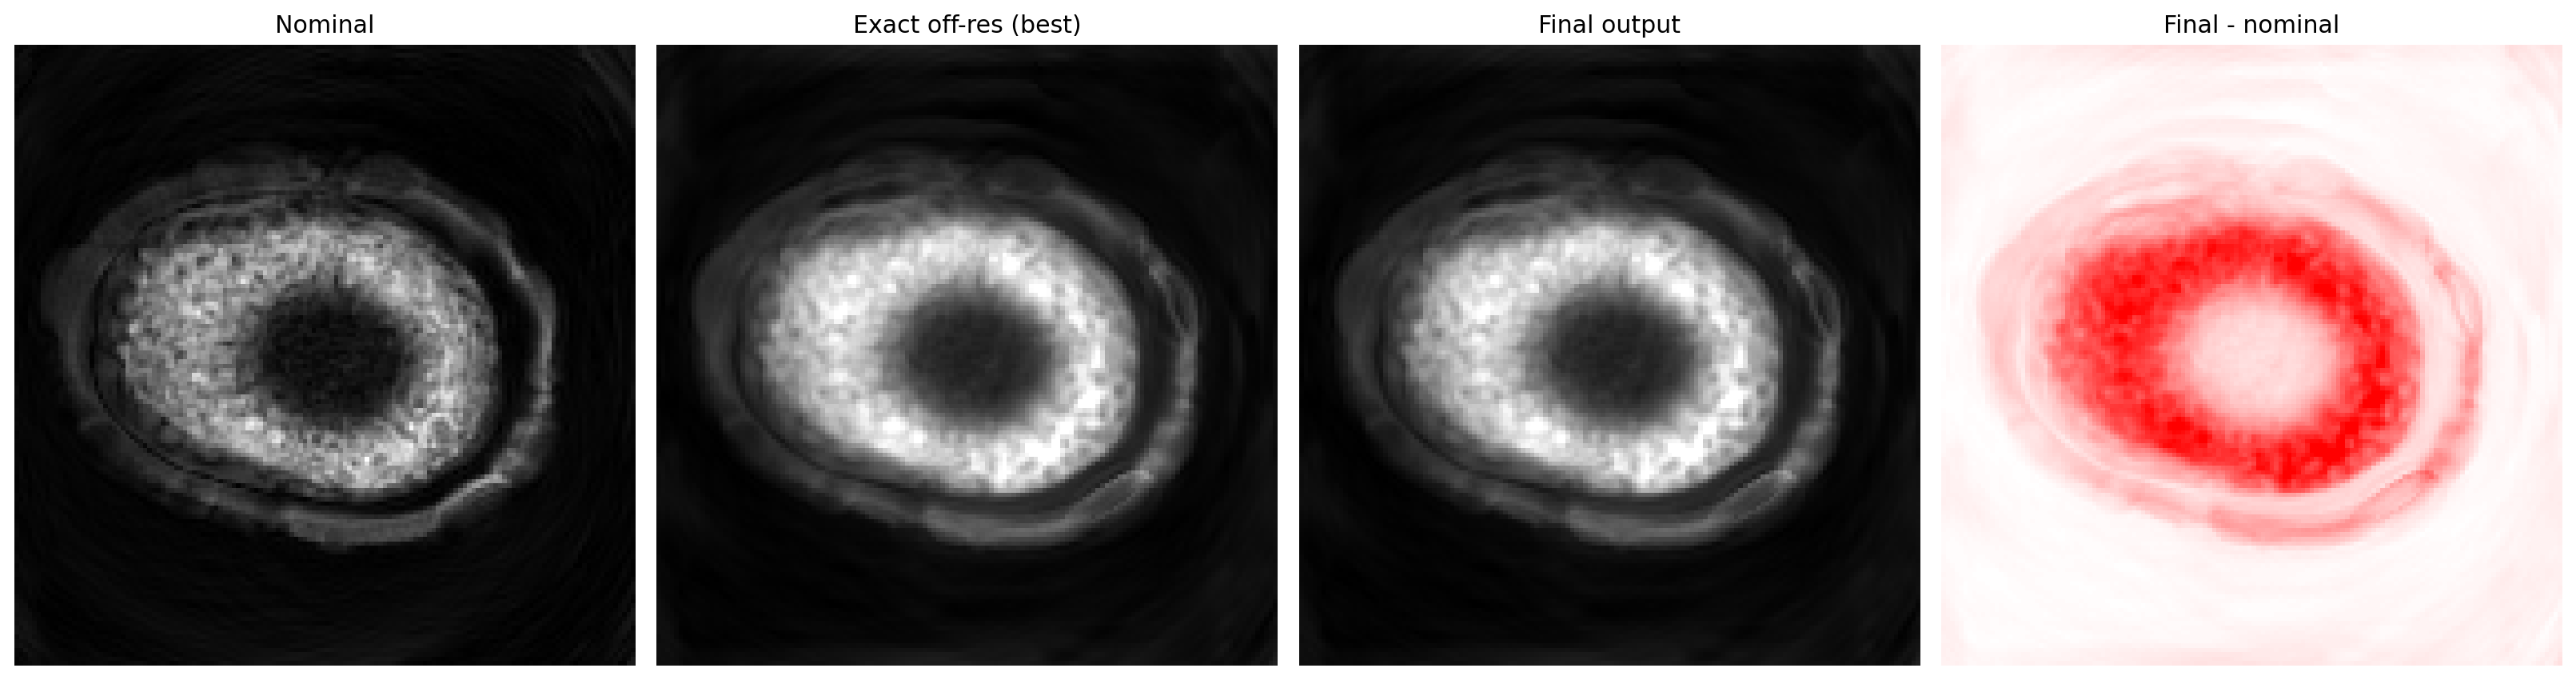

Exact-model candidates:


In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4.8), dpi=180)
ax[0].imshow(mag_nom.T, cmap="gray")
ax[0].set_title("Nominal")
ax[0].axis("off")

ax[1].imshow(mag_exact.T, cmap="gray", vmin=0, vmax=vmax)
ax[1].set_title("Exact off-res (best)")
ax[1].axis("off")

ax[2].imshow(mag_out.T, cmap="gray", vmin=0, vmax=vmax)
ax[2].set_title("Final output")
ax[2].axis("off")

ax[3].imshow(diff, cmap="bwr", vmin=-mx, vmax=mx)
ax[3].set_title("Final - nominal")
ax[3].axis("off")

plt.tight_layout()
plt.show()

print("Exact-model candidates:")
for i, r in enumerate(results_exact):
    print(
        f"  {i+1:02d}. lamda={r['lamda']:.1e}, score={r['score']:.4f}, "
        f"sharp={r['sharp']:.4e}, contrast={r['contrast']:.4e}, resid={r['resid']:.4e}"
    )

In [633]:
import skope_reader
skope_traj_path = 'skope_data/diffusion_eddy_spiral_20260420.h5'
session = skope_reader.Session(skope_traj_path)
print(session)

1 Camera Locator
| 1.1 Field Model 1
2 fs_se_dti_spiral_vds_b2000_v0.7.2
3 fs_se_dti_spiral_vds_b2000_v0.7.2_rfoff
4 fs_se_dti_spiral_vds_b2000_v0.7.2



In [646]:
trigger_skope_delay = 120e-6 # Time from trigger to first time point recorded in skope data
skope_dwell = 3.584e-6

# traj = session.get_scan(2) # acc=1.0
skope_data = session.get_scan(4) # acc=1.5
# traj = session.get_scan(4) # acc=2.0
skope_traj = skope_data.trajectory
print('Skope trajectory shape:', skope_traj.shape)
print(skope_data.description)

adc_start_s = 50.27e-3 #+ 5e-6 
trigger_start_s = 47.39e-3

Skope trajectory shape: (840, 20, 22322)
Diffusion End: 47.39 ms
ADC Start: 50.27 ms + 5 us
Skope Start: 47.39 ms + 120 us


In [647]:
# ------------------------------------------------------------------
# Step 6: Reorganize Skope trajectory and align to ADC window
# ------------------------------------------------------------------
import itertools
import re

required = [
    "skope_traj",
    "n_slc",
    "n_shot_use",
    "n_dir_use",
    "n_ro_use",
    "adc_dwell_s",
    "trigger_skope_delay",
    "skope_dwell",
    "adc_start_s",
    "trigger_start_s",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables for Skope alignment: {missing}")

skope_traj_raw = np.asarray(skope_traj, dtype=np.float32)
if skope_traj_raw.ndim != 3:
    raise RuntimeError(f"Expected Skope trajectory with 3 dims, got shape {skope_traj_raw.shape}")

# Normalize Skope axis order to (frame, dim, time).
if skope_traj_raw.shape[1] > skope_traj_raw.shape[2]:
    skope_traj_raw = np.transpose(skope_traj_raw, (0, 2, 1))

n_frame, n_dim, n_time = [int(v) for v in skope_traj_raw.shape]
if n_dim < 3:
    raise RuntimeError(f"Unexpected Skope dim count: {n_dim}. Need at least [B0, Gx, Gy].")

n_slc_data = int(n_slc)
n_dir_data = int(n_dir_use)
n_shot_data = int(n_shot_use)
n_rep_target = int(n_rep) if "n_rep" in globals() else int(num_repeats)

frames_per_rep = int(n_slc_data) * int(n_dir_data) * int(n_shot_data)
if frames_per_rep <= 0:
    raise RuntimeError(
        f"Invalid factor product for Skope reshape: slc={n_slc_data}, dir={n_dir_data}, shot={n_shot_data}"
    )
if n_frame % frames_per_rep != 0:
    raise RuntimeError(
        "Skope frame count does not match expected slice/dir/shot layout. "
        f"n_frame={n_frame}, slc*dir*shot={frames_per_rep}"
    )

n_rep_skope = int(n_frame // frames_per_rep)
factors = {"rep": n_rep_skope, "slc": n_slc_data, "dir": n_dir_data, "shot": n_shot_data}
expected_frames = int(np.prod([factors[k] for k in ["rep", "slc", "dir", "shot"]]))
if expected_frames != n_frame:
    raise RuntimeError(f"Internal mismatch: expected_frames={expected_frames}, n_frame={n_frame}")

print("Skope factors inferred from frame count:", factors, f"| target repeats={n_rep_target}")

# Try all possible frame-order permutations and pick the one that best matches
# designed trajectories (if design coordinates are available).
best_perm = ("rep", "slc", "dir", "shot")
if "coords_by_shot" in globals() and len(coords_by_shot) >= int(n_shot_data):
    t_src = float(trigger_skope_delay) + np.arange(int(n_time), dtype=np.float32) * float(skope_dwell)
    t_adc = float(adc_start_s) + np.arange(int(n_ro_use), dtype=np.float32) * float(adc_dwell_s)

    # Precompute per-frame ADC windows once: (frame, dim, ro)
    frame_adc = np.empty((n_frame, n_dim, int(n_ro_use)), dtype=np.float32)
    for f in range(n_frame):
        for d in range(n_dim):
            frame_adc[f, d] = np.interp(
                t_adc,
                t_src,
                skope_traj_raw[f, d],
                left=skope_traj_raw[f, d, 0],
                right=skope_traj_raw[f, d, -1],
            ).astype(np.float32)

    keys = ["rep", "slc", "dir", "shot"]
    best_score = np.inf
    for perm in itertools.permutations(keys):
        shp = [factors[k] for k in perm]
        x = frame_adc.reshape(*shp, n_dim, int(n_ro_use))
        axes = [perm.index("rep"), perm.index("slc"), perm.index("dir"), perm.index("shot"), 4, 5]
        can = np.transpose(x, axes=axes)  # (rep, slc, dir, shot, dim, ro)

        errs = []
        for shot_idx in range(int(n_shot_data)):
            kx = np.mean(can[:, :, 0, shot_idx, 1, :], axis=(0, 1)) / (2 * np.pi)
            ky = np.mean(can[:, :, 0, shot_idx, 2, :], axis=(0, 1)) / (2 * np.pi)

            tgt = np.asarray(coords_by_shot[shot_idx], dtype=np.float32)
            if tgt.shape[0] != kx.shape[0]:
                n = min(tgt.shape[0], kx.shape[0])
                tgt = tgt[:n]
                kx = kx[:n]
                ky = ky[:n]

            m_raw = np.stack([kx, ky, np.ones_like(kx)], axis=1)
            c_raw, *_ = np.linalg.lstsq(m_raw, tgt, rcond=None)
            e_raw = np.linalg.norm(m_raw @ c_raw - tgt) / max(np.linalg.norm(tgt), 1e-8)

            kx_i = np.cumsum(kx) * float(adc_dwell_s)
            ky_i = np.cumsum(ky) * float(adc_dwell_s)
            kx_i -= kx_i[0]
            ky_i -= ky_i[0]
            m_int = np.stack([kx_i, ky_i, np.ones_like(kx_i)], axis=1)
            c_int, *_ = np.linalg.lstsq(m_int, tgt, rcond=None)
            e_int = np.linalg.norm(m_int @ c_int - tgt) / max(np.linalg.norm(tgt), 1e-8)

            errs.append(min(float(e_raw), float(e_int)))

        score = float(np.mean(errs))
        if score < best_score:
            best_score = score
            best_perm = perm

    print("Selected Skope frame-order permutation:", best_perm, f"(score={best_score:.4f})")

# Reorganize raw Skope trajectory using selected permutation.
reshape_shape = [factors[k] for k in best_perm]
x_raw = skope_traj_raw.reshape(*reshape_shape, n_dim, n_time)
axes = [best_perm.index("rep"), best_perm.index("slc"), best_perm.index("dir"), best_perm.index("shot"), 4, 5]
skope_traj_reorg = np.transpose(x_raw, axes=axes)

# If only one Skope repeat was recorded, broadcast it to all diffusion repeats.
if skope_traj_reorg.shape[0] != int(n_rep_target):
    if skope_traj_reorg.shape[0] == 1 and int(n_rep_target) > 1:
        skope_traj_reorg = np.repeat(skope_traj_reorg, int(n_rep_target), axis=0)
        print(f"Broadcasting single Skope repeat to {n_rep_target} repeats.")
    elif skope_traj_reorg.shape[0] > int(n_rep_target):
        skope_traj_reorg = skope_traj_reorg[: int(n_rep_target)]
        print(f"Trimming Skope repeats from {factors['rep']} to target {n_rep_target}.")
    else:
        rep_map = np.arange(int(n_rep_target)) % skope_traj_reorg.shape[0]
        skope_traj_reorg = skope_traj_reorg[rep_map]
        print(f"Tiling Skope repeats from {factors['rep']} to target {n_rep_target}.")

n_rep_data, n_slc_data, n_dir_data, n_shot_data, _, _ = skope_traj_reorg.shape

# Build ADC-aligned trajectory windows.
t_src = float(trigger_start_s) + float(trigger_skope_delay) + np.arange(int(n_time), dtype=np.float32) * float(skope_dwell)
t_adc = float(adc_start_s) + np.arange(int(n_ro_use), dtype=np.float32) * float(adc_dwell_s)

def _interp_adc_window(sig_1d):
    return np.interp(t_adc, t_src, sig_1d, left=sig_1d[0], right=sig_1d[-1]).astype(np.float32)

skope_adc_traj = np.empty((
    int(n_rep_data),
    int(n_slc_data),
    int(n_dir_data),
    int(n_shot_data),
    int(n_dim),
    int(n_ro_use),
), dtype=np.float32)
for rep_idx in range(int(n_rep_data)):
    for slc_idx in range(int(n_slc_data)):
        for dir_idx in range(int(n_dir_data)):
            for shot_idx in range(int(n_shot_data)):
                for dim_idx in range(int(n_dim)):
                    sig = skope_traj_reorg[rep_idx, slc_idx, dir_idx, shot_idx, dim_idx]
                    skope_adc_traj[rep_idx, slc_idx, dir_idx, shot_idx, dim_idx] = _interp_adc_window(sig)

print("Raw Skope shape:", skope_traj_raw.shape)
print("Reorganized Skope shape (rep, slc, dir, shot, dim, time):", skope_traj_reorg.shape)
print("Aligned ADC Skope shape (rep, slc, dir, shot, dim, ro):", skope_adc_traj.shape)
print(f"ADC start used: {adc_start_s*1e3:.4f} ms")
print(f"ADC dwell used: {adc_dwell_s*1e6:.4f} us")

Skope factors inferred from frame count: {'rep': 1, 'slc': 3, 'dir': 7, 'shot': 40} | target repeats=8
Selected Skope frame-order permutation: ('rep', 'slc', 'dir', 'shot') (score=0.9029)
Broadcasting single Skope repeat to 8 repeats.
Raw Skope shape: (840, 20, 22322)
Reorganized Skope shape (rep, slc, dir, shot, dim, time): (8, 3, 7, 40, 20, 22322)
Aligned ADC Skope shape (rep, slc, dir, shot, dim, ro): (8, 3, 7, 40, 20, 5528)
ADC start used: 50.2700 ms
ADC dwell used: 1.0000 us


(8, 3, 7, 40, 20, 5528) (8, 3, 7, 40, 20, 22322)


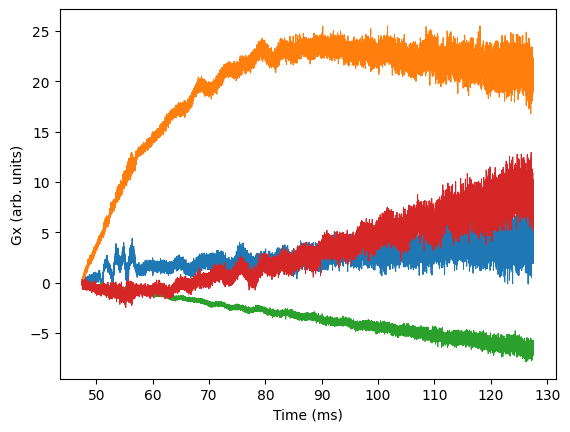

In [707]:
print(skope_adc_traj.shape, skope_traj_reorg.shape)
plt.plot(t_src * 1e3, (skope_traj_reorg[0, :, 3, :, 4:8, :]+skope_traj_reorg[0, :, 4, :, 4:8, :] - skope_traj_reorg[0, :, 0, :, 4:8, :] * 2).mean(axis=(0,1)).T, label='Gx (raw)')
# plt.plot(t_src * 1e3, (skope_traj_reorg[0, :, 2, :, :16, :]-skope_traj_reorg[0, :, 0, :, :16, :]).mean(axis=(0,1)).T, label='Gx (raw)')
# plt.plot(t_src[:] * 1e3, ((skope_traj_reorg[0, :, 4, :, 4:16, :]-skope_traj_reorg[0, :, 0, :, 4:16, :]).mean(axis=(0,1))).T)
plt.xlabel('Time (ms)')
plt.ylabel('Gx (arb. units)')
# plt.xlim(48,60)
plt.show()

In [649]:
# ------------------------------------------------------------------
# Step 7: Skope first-order non-Cartesian NUFFT-SENSE reconstruction
# ------------------------------------------------------------------
import time

required = [
    "sp_data", "sens_use", "recon_nx", "recon_ny", "skope_adc_traj",
    "n_rep", "n_slc", "n_dir_use", "n_shot_use", "n_ro_use"
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables for Skope first-order recon: {missing}")

if skope_adc_traj.shape[-2] < 3:
    raise RuntimeError("Skope trajectory has fewer than 3 channels. Need at least [B0, Gx, Gy].")

# Use trajectory averaged across rep/slc/dir for robust coordinate estimation.
skope_xy_avg = np.mean(
    skope_adc_traj[:, :, :int(n_dir_use), :, 1:3, :],
    axis=(0, 1, 2),
).astype(np.float32)  # (shot, 2, ro)

def _affine_fit(meas_x, meas_y, target_coord):
    m = np.stack(
        [
            meas_x.astype(np.float32),
            meas_y.astype(np.float32),
            np.ones_like(meas_x, dtype=np.float32),
        ],
        axis=1,
    )
    coef, *_ = np.linalg.lstsq(m, target_coord.astype(np.float32), rcond=None)  # (3, 2)
    pred = m @ coef
    err = np.linalg.norm(pred - target_coord) / max(np.linalg.norm(target_coord), 1e-8)
    return coef.astype(np.float32), float(err)

# Calibrate Skope first-order channels -> design SigPy coordinates via affine fit per shot.
skope_affine_by_shot = []
skope_mode_by_shot = []
design_center_by_shot = []
design_rms_by_shot = []
if "coords_by_shot" in globals() and len(coords_by_shot) >= int(n_shot_use):
    for shot_idx in range(int(n_shot_use)):
        kx_raw = skope_xy_avg[shot_idx, 0] / (2 * np.pi)
        ky_raw = skope_xy_avg[shot_idx, 1] / (2 * np.pi)

        target = np.asarray(coords_by_shot[shot_idx], dtype=np.float32)
        if target.shape[0] != int(n_ro_use):
            target = target[: int(n_ro_use)]
            kx_raw = kx_raw[: target.shape[0]]
            ky_raw = ky_raw[: target.shape[0]]

        target_center = np.mean(target, axis=0)
        target0 = target - target_center
        target_rms = float(np.sqrt(np.mean(np.sum(target0 ** 2, axis=1))))

        coef_raw, err_raw = _affine_fit(kx_raw, ky_raw, target)

        dt = float(adc_dwell_s) if "adc_dwell_s" in globals() else float(skope_dwell)
        kx_int = np.cumsum(kx_raw.astype(np.float64)) * dt
        ky_int = np.cumsum(ky_raw.astype(np.float64)) * dt
        kx_int -= kx_int[0]
        ky_int -= ky_int[0]
        coef_int, err_int = _affine_fit(kx_int.astype(np.float32), ky_int.astype(np.float32), target)

        if err_int < err_raw:
            skope_affine_by_shot.append(coef_int)
            skope_mode_by_shot.append("int")
        else:
            skope_affine_by_shot.append(coef_raw)
            skope_mode_by_shot.append("raw")

        design_center_by_shot.append(target_center.astype(np.float32))
        design_rms_by_shot.append(max(target_rms, 1e-8))

    print("Built affine Skope->design calibration for", len(skope_affine_by_shot), "shots")
    print("Per-shot mode counts:", {m: skope_mode_by_shot.count(m) for m in set(skope_mode_by_shot)})
else:
    print("coords_by_shot not available; using direct kmax normalization fallback")

# Conservative blend keeps images stable while still injecting measured trajectory effects.
skope_coord_blend = 0.01
print(f"Using Skope/design coordinate blend alpha = {skope_coord_blend:.2f}")

# Local helpers reused by high-order reconstruction in the next cell.
def _concat_data_pts(rep_idx, slc_idx, dir_idx):
    d_frame = np.asarray(
        sp_data[rep_idx, slc_idx, dir_idx, :n_shot_use, :, :n_ro_use],
        dtype=np.complex64,
    )
    return np.concatenate([d_frame[s] for s in range(n_shot_use)], axis=-1).astype(np.complex64)

def _coord_from_skope_shot(rep_idx, slc_idx, dir_idx, shot_idx):
    kx_raw = skope_xy_avg[shot_idx, 0] / (2 * np.pi)
    ky_raw = skope_xy_avg[shot_idx, 1] / (2 * np.pi)

    if len(skope_affine_by_shot) == int(n_shot_use):
        if skope_mode_by_shot[shot_idx] == "int":
            dt = float(adc_dwell_s) if "adc_dwell_s" in globals() else float(skope_dwell)
            kx_feat = np.cumsum(kx_raw.astype(np.float64)) * dt
            ky_feat = np.cumsum(ky_raw.astype(np.float64)) * dt
            kx_feat -= kx_feat[0]
            ky_feat -= ky_feat[0]
            kx_feat = kx_feat.astype(np.float32)
            ky_feat = ky_feat.astype(np.float32)
        else:
            kx_feat = kx_raw.astype(np.float32)
            ky_feat = ky_raw.astype(np.float32)

        m = np.stack(
            [
                kx_feat,
                ky_feat,
                np.ones_like(kx_feat, dtype=np.float32),
            ],
            axis=1,
        )
        coord = (m @ skope_affine_by_shot[shot_idx]).astype(np.float32)

        c0 = coord - np.mean(coord, axis=0)
        c_rms = float(np.sqrt(np.mean(np.sum(c0 ** 2, axis=1))))
        scale = float(design_rms_by_shot[shot_idx]) / max(c_rms, 1e-8)
        coord = c0 * scale + design_center_by_shot[shot_idx]

        coord[:, 0] = np.clip(coord[:, 0], -recon_ny / 2.0, recon_ny / 2.0)
        coord[:, 1] = np.clip(coord[:, 1], -recon_nx / 2.0, recon_nx / 2.0)
    else:
        coord_y = (ky_raw / max(float(kmax_y), 1e-9)) * (recon_ny / 2.0)
        coord_x = (kx_raw / max(float(kmax_x), 1e-9)) * (recon_nx / 2.0)
        coord = np.stack((coord_y, coord_x), axis=-1).astype(np.float32)

    if "coords_by_shot" in globals() and len(coords_by_shot) > shot_idx:
        coord_design = np.asarray(coords_by_shot[shot_idx], dtype=np.float32)
        if coord_design.shape[0] != coord.shape[0]:
            n = min(coord_design.shape[0], coord.shape[0])
            coord_design = coord_design[:n]
            coord = coord[:n]
        coord = ((1.0 - skope_coord_blend) * coord_design + skope_coord_blend * coord).astype(np.float32)

    return coord

def _concat_skope_coord(rep_idx, slc_idx, dir_idx):
    coord_list = [_coord_from_skope_shot(rep_idx, slc_idx, dir_idx, s) for s in range(int(n_shot_use))]
    return np.concatenate(coord_list, axis=0)

img_sense_skope_fo = np.zeros((n_rep, n_slc, n_dir_use, recon_ny, recon_nx), dtype=np.complex64)

total_items = int(n_rep) * int(n_slc) * int(n_dir_use)
t0 = time.time()
print("Starting Skope first-order NUFFT-SENSE reconstruction ...")

with tqdm(total=total_items, desc="Skope FO NUFFT-SENSE", leave=False) as pbar:
    for rep_idx in range(int(n_rep)):
        for slc_idx in range(int(n_slc)):
            mps_gpu = sp.to_device(np.asarray(sens_use[slc_idx], dtype=np.complex64), _sp_device)

            for dir_idx in range(int(n_dir_use)):
                y_cat = _concat_data_pts(rep_idx, slc_idx, dir_idx)
                coord_cat = _concat_skope_coord(rep_idx, slc_idx, dir_idx)

                y_gpu = sp.to_device(y_cat, _sp_device)
                coord_gpu = sp.to_device(coord_cat, _sp_device)
                dcf_gpu = sp.mri.dcf.pipe_menon_dcf(
                    coord_gpu,
                    img_shape=(recon_ny, recon_nx),
                    max_iter=15,
                    show_pbar=False,
                    device=_sp_device,
                )

                app = sp.mri.app.SenseRecon(
                    y=y_gpu,
                    mps=mps_gpu,
                    coord=coord_gpu,
                    weights=dcf_gpu,
                    max_iter=30,
                    lamda=1e-3,
                    device=_sp_device,
                    solver="PrimalDualHybridGradient",
                    show_pbar=False,
                )

                recon_gpu = app.run()
                img_sense_skope_fo[rep_idx, slc_idx, dir_idx] = np.asarray(
                    sp.to_device(recon_gpu, sp.Device(-1)),
                    dtype=np.complex64,
                )
                pbar.update(1)

print(f"Skope first-order reconstruction done in {time.time()-t0:.1f}s")
print("Image shape:", img_sense_skope_fo.shape)

coord_test = _concat_skope_coord(0, 0, 0)
print("coord y min/max:", float(coord_test[:, 0].min()), float(coord_test[:, 0].max()))
print("coord x min/max:", float(coord_test[:, 1].min()), float(coord_test[:, 1].max()))

Built affine Skope->design calibration for 40 shots
Per-shot mode counts: {'raw': 40}
Using Skope/design coordinate blend alpha = 0.01
Starting Skope first-order NUFFT-SENSE reconstruction ...


Skope FO NUFFT-SENSE:   0%|          | 0/168 [00:00<?, ?it/s]

Skope first-order reconstruction done in 115.5s
Image shape: (8, 3, 7, 256, 256)
coord y min/max: -127.99958038330078 128.0
coord x min/max: -127.99983215332031 127.99993133544922


In [650]:
# ------------------------------------------------------------------
# Step 8: High-order-informed inverse reconstruction (moment demodulation)
# EPI-aligned basis support + fast hybrid spiral solve
# ------------------------------------------------------------------
if "img_sense_skope_fo" not in globals():
    raise RuntimeError("img_sense_skope_fo not found. Run first-order Skope reconstruction first.")

n_basis_total = int(skope_adc_traj.shape[-2])
if n_basis_total <= 3:
    raise RuntimeError("No high-order channels available in Skope trajectory (need dim > 3).")

# Match EPI reference behavior: use fov in meters when available.
fov_m = float(fov_mm) * 1e-3 if "fov_mm" in globals() else (float(fov) if "fov" in globals() else 0.220)
x_m = ((np.arange(recon_nx, dtype=np.float32) - recon_nx / 2.0) / max(float(recon_nx), 1.0)) * fov_m
y_m = ((np.arange(recon_ny, dtype=np.float32) - recon_ny / 2.0) / max(float(recon_ny), 1.0)) * fov_m
Y_m, X_m = np.meshgrid(y_m, x_m, indexing="ij")

# Keep default aligned with EPI workflow sparsity unless user overrides.
ho_basis_mode = str(globals().get("ho_basis_mode", "epi_sparse")).lower()

def _basis_maps(z0_m, n_basis):
    """
    Build spatial basis maps. In epi_sparse mode, mimic EPI high-order cell:
    keep 0..3 and 16..19 terms active, leave 4..15 as zeros.
    """
    x = X_m.astype(np.float32)
    y = Y_m.astype(np.float32)
    z = np.full_like(x, float(z0_m), dtype=np.float32)
    r2 = x * x + y * y + z * z

    if ho_basis_mode == "epi_sparse":
        basis = [np.zeros_like(x, dtype=np.float32) for _ in range(max(int(n_basis), 20))]
        basis[0] = np.ones_like(x, dtype=np.float32)            # global
        basis[1] = x                                             # x
        basis[2] = y                                             # y
        basis[3] = z                                             # z
        basis[16] = z * z                                        # concomitant z^2
        basis[17] = x * x + y * y                                # concomitant x^2 + y^2
        basis[18] = x * z                                        # concomitant xz
        basis[19] = y * z                                        # concomitant yz
        return np.stack(basis[:n_basis], axis=0).astype(np.float32, copy=False)

    # Full polynomial basis (fallback mode)
    basis = [
        np.ones_like(x, dtype=np.float32),              # 0: global (B0-like)
        x,                                               # 1: x
        y,                                               # 2: y
        z,                                               # 3: z
        x * y,                                           # 4: xy
        y * z,                                           # 5: yz
        3.0 * z * z - r2,                               # 6: 3z^2 - r^2
        x * z,                                           # 7: xz
        x * x - y * y,                                   # 8: x^2 - y^2
        3.0 * y * x * x - y * y * y,                    # 9: 3yx^2 - y^3
        x * y * z,                                       # 10: xyz
        5.0 * y * z * z - y * r2,                       # 11: 5yz^2 - y r^2
        5.0 * z * z * z - 3.0 * z * r2,                 # 12: 5z^3 - 3z r^2
        5.0 * x * z * z - x * r2,                       # 13: 5xz^2 - x r^2
        z * x * x - z * y * y,                          # 14: z(x^2 - y^2)
        x * x * x - 3.0 * x * y * y,                    # 15: x^3 - 3xy^2
        z * z,                                           # 16: concomitant z^2
        x * x + y * y,                                   # 17: concomitant x^2 + y^2
        x * z,                                           # 18: concomitant xz
        y * z,                                           # 19: concomitant yz
    ]

    if n_basis > len(basis):
        for _ in range(n_basis - len(basis)):
            basis.append(np.zeros_like(x, dtype=np.float32))

    return np.stack(basis[:n_basis], axis=0).astype(np.float32, copy=False)

# Practical tuning knob: coefficient units can differ between scans.
ho_phase_scale = float(globals().get("ho_phase_scale", 1.0))

if ho_basis_mode == "epi_sparse":
    high_idx = np.array([16, 17, 18, 19], dtype=int)
    high_idx = high_idx[high_idx < n_basis_total]
else:
    high_idx = np.arange(3, n_basis_total, dtype=int)

print(f"Using basis mode: {ho_basis_mode}")
print(f"Using reference basis ordering with {min(n_basis_total, 20)} populated terms (total dim={n_basis_total}).")
print(f"Using high-order phase scale: {ho_phase_scale:.3f}")
print("Active high-order indices:", high_idx.tolist())

img_sense_skope_ho = np.zeros_like(img_sense_skope_fo)

total_items = int(n_rep) * int(n_slc) * int(n_dir_use)
t0 = time.time()
print("Starting high-order-informed inverse reconstruction ...")

with tqdm(total=total_items, desc="Skope HO inverse", leave=False) as pbar:
    for rep_idx in range(int(n_rep)):
        for slc_idx in range(int(n_slc)):
            z0_m = 0.0
            if "slice_offsets" in globals() and len(slice_offsets) > slc_idx:
                z0_m = float(slice_offsets[slc_idx]) * 1e-3

            mps_gpu = sp.to_device(np.asarray(sens_use[slc_idx], dtype=np.complex64), _sp_device)

            for dir_idx in range(int(n_dir_use)):
                # Build trajectory/coeff concatenation over shots
                coord_cat = _concat_skope_coord(rep_idx, slc_idx, dir_idx)
                coeff_cat = np.concatenate(
                    [
                        np.asarray(skope_adc_traj[rep_idx, slc_idx, dir_idx, shot_idx], dtype=np.float32)
                        for shot_idx in range(int(n_shot_use))
                    ],
                    axis=-1,
                )  # (dim, pts)

                # First-order image drives object moments for high-order phase demodulation
                img_ref = np.asarray(img_sense_skope_fo[rep_idx, slc_idx, dir_idx], dtype=np.complex64)
                w = np.abs(img_ref).astype(np.float32)
                w_sum = float(np.sum(w))
                if not np.isfinite(w_sum) or w_sum <= 0:
                    w = np.ones_like(w, dtype=np.float32)
                    w_sum = float(np.sum(w))
                w /= w_sum

                basis = _basis_maps(z0_m, n_basis_total)
                moments = np.tensordot(basis, w, axes=([1, 2], [0, 1])).astype(np.float32)  # (dim,)

                phi_hi = 2.0 * np.pi * np.dot(moments[high_idx], coeff_cat[high_idx, :]) if len(high_idx) > 0 else np.zeros(coeff_cat.shape[-1], dtype=np.float32)

                # Wrap (do not clip) and apply explicit scaling.
                phi_hi = (np.remainder(phi_hi + np.pi, 2.0 * np.pi) - np.pi).astype(np.float32)
                phi_hi = (ho_phase_scale * phi_hi).astype(np.float32)
                demod = np.exp(-1j * phi_hi).astype(np.complex64)

                y_cat = _concat_data_pts(rep_idx, slc_idx, dir_idx)
                y_corr = (y_cat * demod[None, :]).astype(np.complex64)

                y_gpu = sp.to_device(y_corr, _sp_device)
                coord_gpu = sp.to_device(coord_cat, _sp_device)
                dcf_gpu = sp.mri.dcf.pipe_menon_dcf(
                    coord_gpu,
                    img_shape=(recon_ny, recon_nx),
                    max_iter=15,
                    show_pbar=False,
                    device=_sp_device,
                )

                app = sp.mri.app.SenseRecon(
                    y=y_gpu,
                    mps=mps_gpu,
                    coord=coord_gpu,
                    weights=dcf_gpu,
                    max_iter=30,
                    lamda=1e-3,
                    solver="PrimalDualHybridGradient",
                    device=_sp_device,
                    show_pbar=False,
                )

                recon_gpu = app.run()
                img_sense_skope_ho[rep_idx, slc_idx, dir_idx] = np.asarray(
                    sp.to_device(recon_gpu, sp.Device(-1)),
                    dtype=np.complex64,
                )
                pbar.update(1)

print(f"High-order-informed reconstruction done in {time.time()-t0:.1f}s")
print("Image shape:", img_sense_skope_ho.shape)

Using basis mode: epi_sparse
Using reference basis ordering with 20 populated terms (total dim=20).
Using high-order phase scale: 1.000
Active high-order indices: [16, 17, 18, 19]
Starting high-order-informed inverse reconstruction ...


Skope HO inverse:   0%|          | 0/168 [00:00<?, ?it/s]

High-order-informed reconstruction done in 123.1s
Image shape: (8, 3, 7, 256, 256)


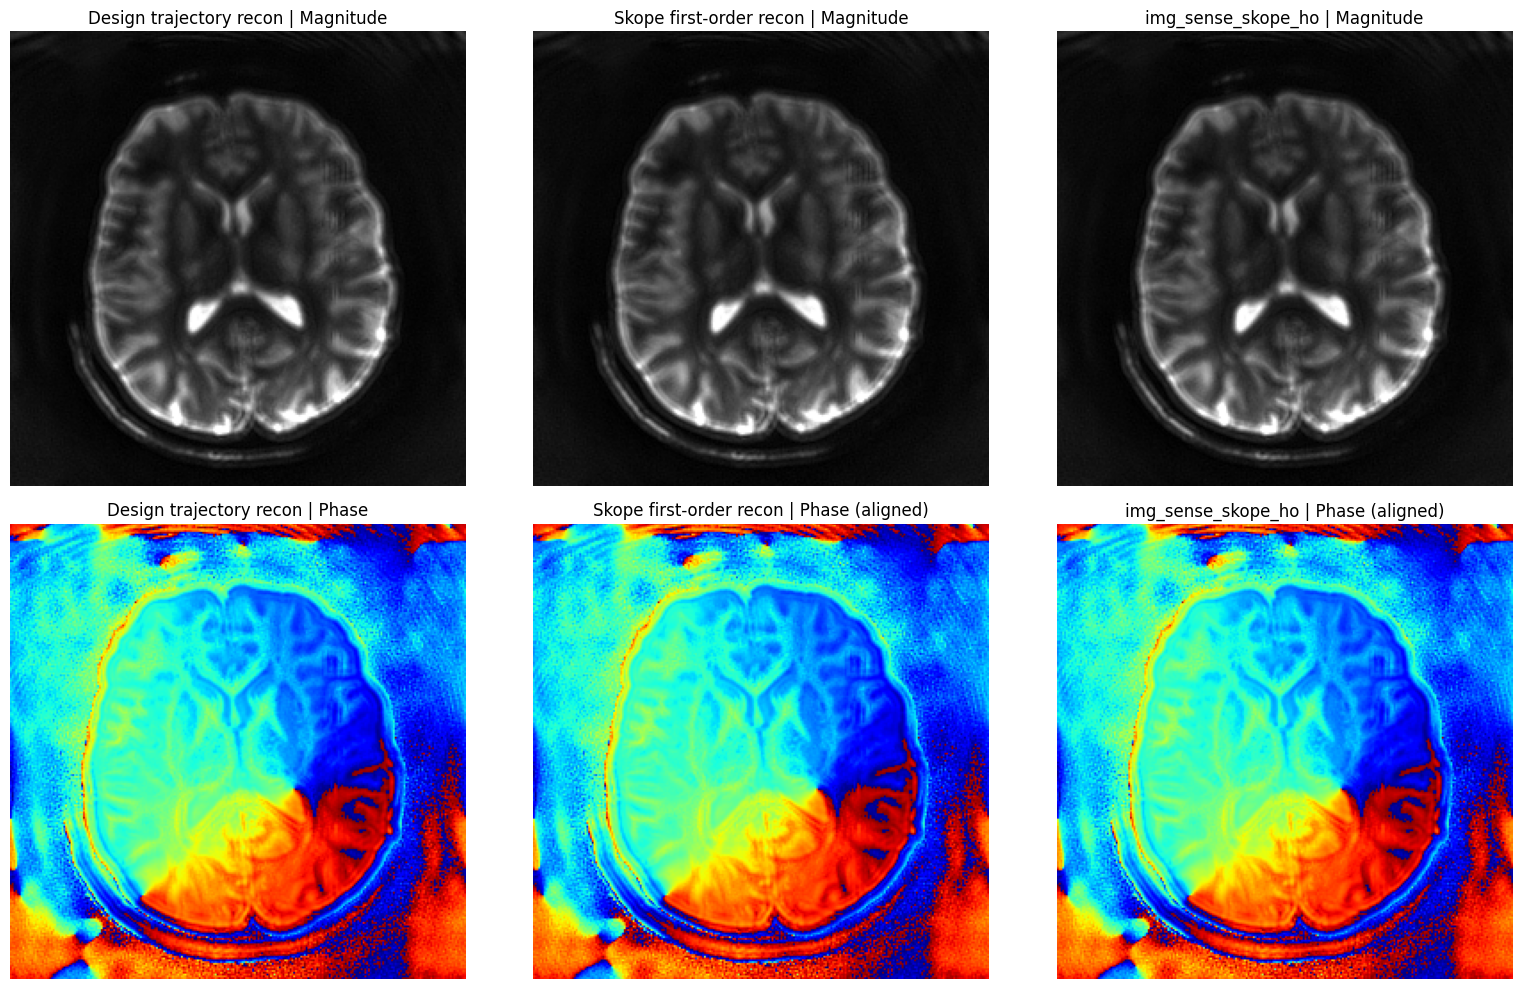

NRMSE(high-order vs first-order) = 5.4638e-10
NRMSE(first-order vs design)    = 1.2447e-06
NRMSE(high-order vs design)     = 1.2446e-06
Complex NRMSE(HO vs FO, aligned)= 7.3066e-10
Global phase offset FO vs ref [deg]: -0.01
Global phase offset HO vs ref [deg]: -0.01
HO source used: img_sense_skope_ho
Display vmax | design: 2.439926516037416e-13 | FO: 2.440e-13 | HO: 2.440e-13


In [652]:
# ------------------------------------------------------------------
# Step 9: Compare design trajectory, Skope first-order, and high-order inverse
# ------------------------------------------------------------------
img_ref = np.mean(img_sense_spiral, axis=0) if "img_sense_spiral" in globals() else None
img_fo = np.mean(img_sense_skope_fo, axis=0)

ho_source = "img_sense_skope_ho"
if "img_sense_skope_ho_exact" in globals():
    ho_source = "img_sense_skope_ho_exact"
img_ho = np.mean(globals()[ho_source], axis=0)

slc_show = 1
dir_show = 5

img_ref_d = img_ref[slc_show, dir_show].T if img_ref is not None else None
img_fo_d = img_fo[slc_show, dir_show].T
img_ho_d = img_ho[slc_show, dir_show].T

# Align global phase so panel differences reflect spatial phase structure.
def _phase_align_to_ref(img, ref):
    ph = np.angle(np.vdot(ref.ravel(), img.ravel()))
    return img * np.exp(-1j * ph), float(ph)

if img_ref_d is not None:
    img_fo_disp, ph_fo = _phase_align_to_ref(img_fo_d, img_ref_d)
    img_ho_disp, ph_ho = _phase_align_to_ref(img_ho_d, img_ref_d)
else:
    img_fo_disp = img_fo_d
    img_ho_disp, ph_ho = _phase_align_to_ref(img_ho_d, img_fo_d)
    ph_fo = 0.0

m_ref = np.abs(img_ref_d) if img_ref_d is not None else None
m_fo = np.abs(img_fo_disp)
m_ho = np.abs(img_ho_disp)

# Use per-panel robust scaling since absolute magnitudes can differ by branch.
def _robust_vmax(x):
    v = float(np.percentile(x, 99.5))
    return v if np.isfinite(v) and v > 0 else 1.0

v_ref = _robust_vmax(m_ref) if m_ref is not None else None
v_fo = _robust_vmax(m_fo)
v_ho = _robust_vmax(m_ho)

if m_ref is not None:
    fig, ax = plt.subplots(2, 3, figsize=(16, 10))
else:
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))

if m_ref is not None:
    ax[0, 0].imshow(m_ref.T, cmap="gray", vmin=0, vmax=v_ref)
    ax[0, 0].set_title("Design trajectory recon | Magnitude")
    ax[1, 0].imshow(np.angle(img_ref_d).T, cmap="jet", vmin=-np.pi, vmax=np.pi)
    ax[1, 0].set_title("Design trajectory recon | Phase")

col_fo = 1 if m_ref is not None else 0
col_ho = 2 if m_ref is not None else 1

ax[0, col_fo].imshow(m_fo.T, cmap="gray", vmin=0, vmax=v_fo)
ax[0, col_fo].set_title("Skope first-order recon | Magnitude")
ax[1, col_fo].imshow(np.angle(img_fo_disp).T, cmap="jet", vmin=-np.pi, vmax=np.pi)
ax[1, col_fo].set_title("Skope first-order recon | Phase (aligned)")

ax[0, col_ho].imshow(m_ho.T, cmap="gray", vmin=0, vmax=v_ho)
ax[0, col_ho].set_title(f"{ho_source} | Magnitude")
ax[1, col_ho].imshow(np.angle(img_ho_disp).T, cmap="jet", vmin=-np.pi, vmax=np.pi)
ax[1, col_ho].set_title(f"{ho_source} | Phase (aligned)")

for a in np.ravel(ax):
    a.axis("off")

plt.tight_layout()
plt.show()

# Scalar diagnostics.
num = np.linalg.norm(m_ho - m_fo)
den = max(np.linalg.norm(m_fo), 1e-8)
print(f"NRMSE(high-order vs first-order) = {num/den:.4e}")
if m_ref is not None:
    num_ref_fo = np.linalg.norm(m_fo - m_ref)
    den_ref = max(np.linalg.norm(m_ref), 1e-8)
    num_ref_ho = np.linalg.norm(m_ho - m_ref)
    print(f"NRMSE(first-order vs design)    = {num_ref_fo/den_ref:.4e}")
    print(f"NRMSE(high-order vs design)     = {num_ref_ho/den_ref:.4e}")

num_c = np.linalg.norm(img_ho_disp - img_fo_disp)
den_c = max(np.linalg.norm(img_fo_disp), 1e-8)
print(f"Complex NRMSE(HO vs FO, aligned)= {num_c/den_c:.4e}")
if m_ref is not None:
    print(f"Global phase offset FO vs ref [deg]: {np.degrees(ph_fo):.2f}")
print(f"Global phase offset HO vs ref [deg]: {np.degrees(ph_ho):.2f}")
print(f"HO source used: {ho_source}")
print(f"Display vmax | design: {v_ref if v_ref is not None else 'n/a'} | FO: {v_fo:.3e} | HO: {v_ho:.3e}")

In [672]:
# ------------------------------------------------------------------
# Step 8b: EPI-style high-order operator adapted to spiral (segmented NUFFT)
# ------------------------------------------------------------------

# Why segmented?
# EPI high-order code uses explicit phase encoding for Cartesian data.
# For spiral, first-order encoding is non-Cartesian and should stay in NUFFT.
# We therefore keep NUFFT for first-order trajectory and inject high-order
# terms through a time-segmented spatial phase operator.

required = [
    "sp", "np", "recon_ny", "recon_nx", "sens_use", "_sp_device",
    "_concat_data_pts", "_concat_skope_coord", "skope_adc_traj",
    "_basis_maps", "img_sense_skope_fo"
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing prerequisites for spiral exact HO recon: {missing}")


class SpiralHighOrderSegmentedLinop(sp.linop.Linop):
    def __init__(
        self,
        img_shape,
        sens,
        coord,
        coeff_high,
        basis_high,
        device,
        nseg=8,
        phase_scale=1.0,
        weights_sqrt=None,
    ):
        self.device = sp.Device(device)
        self.ny, self.nx = img_shape
        self.phase_scale = float(phase_scale)

        self.sens = sp.to_device(np.asarray(sens, dtype=np.complex64), self.device)
        self.coord = sp.to_device(np.asarray(coord, dtype=np.float32), self.device)
        self.coeff_high = sp.to_device(np.asarray(coeff_high, dtype=np.float32), self.device)
        self.basis_high = sp.to_device(np.asarray(basis_high, dtype=np.float32), self.device)

        self.nc = int(self.sens.shape[0])
        self.ns = int(self.coord.shape[0])
        self.nh = int(self.coeff_high.shape[0])

        if weights_sqrt is None:
            self.weights_sqrt = None
        else:
            ws = np.asarray(weights_sqrt, dtype=np.float32).reshape(-1)
            if ws.shape[0] != self.ns:
                raise ValueError(f"weights_sqrt length mismatch: {ws.shape[0]} vs ns={self.ns}")
            self.weights_sqrt = sp.to_device(ws, self.device)

        nseg = max(1, min(int(nseg), self.ns))
        self.seg_idx = [
            np.asarray(v, dtype=np.int32)
            for v in np.array_split(np.arange(self.ns, dtype=np.int32), nseg)
            if len(v) > 0
        ]

        # Precompute per-segment phase maps.
        self.seg_mod_fwd = []
        self.seg_mod_adj = []
        for idx in self.seg_idx:
            cseg = self.coeff_high[:, idx].mean(axis=1)  # (nh,)
            phi = 2.0 * np.pi * self.phase_scale * np.tensordot(cseg, self.basis_high, axes=([0], [0]))  # (ny, nx)
            mod = self.device.xp.exp(-1j * phi).astype(self.device.xp.complex64, copy=False)
            self.seg_mod_fwd.append(mod)
            self.seg_mod_adj.append(self.device.xp.conj(mod))

        super().__init__((self.nc, self.ns), (self.ny, self.nx))

    def _apply(self, x):
        xp = self.device.xp
        x = sp.to_device(x, self.device).astype(xp.complex64, copy=False)
        y = xp.zeros((self.nc, self.ns), dtype=xp.complex64)

        for sidx, idx in enumerate(self.seg_idx):
            coord_seg = self.coord[idx]
            mod = self.seg_mod_fwd[sidx]
            for c in range(self.nc):
                xc = self.sens[c] * x
                xc = mod * xc
                y[c, idx] = sp.nufft(xc, coord_seg)

        # Weighted least squares: A_w = W^(1/2) A
        if self.weights_sqrt is not None:
            y = y * self.weights_sqrt[None, :]

        return y

    def _adjoint_linop(self):
        return SpiralHighOrderSegmentedAdjointLinop(self)


class SpiralHighOrderSegmentedAdjointLinop(sp.linop.Linop):
    def __init__(self, parent):
        self.parent = parent
        super().__init__(parent.ishape, parent.oshape)

    def _apply(self, y):
        p = self.parent
        xp = p.device.xp
        y = sp.to_device(y, p.device).astype(xp.complex64, copy=False)

        # Adjoint of A_w = W^(1/2) A is A^H W^(1/2)
        if p.weights_sqrt is not None:
            y = y * p.weights_sqrt[None, :]

        x_acc = xp.zeros((p.ny, p.nx), dtype=xp.complex64)

        for sidx, idx in enumerate(p.seg_idx):
            coord_seg = p.coord[idx]
            mod_adj = p.seg_mod_adj[sidx]
            for c in range(p.nc):
                tmp = sp.nufft_adjoint(y[c, idx], coord_seg, oshape=(p.ny, p.nx))
                x_acc += xp.conj(p.sens[c]) * (mod_adj * tmp)

        return x_acc

    def _adjoint_linop(self):
        return self.parent


class SpiralHighOrderSegmentedRecon(sp.app.LinearLeastSquares):
    def __init__(
        self,
        y,
        sens,
        coord,
        coeff_high,
        basis_high,
        lamda=0,
        device=sp.cpu_device,
        nseg=8,
        phase_scale=1.0,
        weights_sqrt=None,
        show_pbar=True,
        **kwargs,
    ):
        device = sp.Device(device)
        y = sp.to_device(np.asarray(y, dtype=np.complex64), device=device)

        A = SpiralHighOrderSegmentedLinop(
            img_shape=sens.shape[1:],
            sens=sens,
            coord=coord,
            coeff_high=coeff_high,
            basis_high=basis_high,
            device=device,
            nseg=nseg,
            phase_scale=phase_scale,
            weights_sqrt=weights_sqrt,
        )

        super().__init__(A, y, lamda=lamda, show_pbar=show_pbar, **kwargs)


# Selected case controls.
ho_exact_rep = 0
ho_exact_slc = 1
ho_exact_dir = 0
ho_exact_nseg = max(1, int(globals().get("ho_exact_nseg", 8)))
ho_exact_max_iter = 30
ho_exact_lamda = 1e-18
ho_exact_phase_scale = float(globals().get("ho_exact_phase_scale", 1.0))

print("Running segmented spiral HO recon for case:", (ho_exact_rep, ho_exact_slc, ho_exact_dir))
print(f"nseg={ho_exact_nseg}, max_iter={ho_exact_max_iter}, phase_scale={ho_exact_phase_scale:.3f}, lamda={ho_exact_lamda:.2e}")

# Build data, coord and coefficients.
y_cat = _concat_data_pts(ho_exact_rep, ho_exact_slc, ho_exact_dir)  # (ch, pts)
coord_cat = _concat_skope_coord(ho_exact_rep, ho_exact_slc, ho_exact_dir)  # (pts, 2)
coeff_cat = np.concatenate(
    [
        np.asarray(skope_adc_traj[ho_exact_rep, ho_exact_slc, ho_exact_dir, shot_idx], dtype=np.float32)
        for shot_idx in range(int(n_shot_use))
    ],
    axis=-1,
)  # (dim, pts)

# EPI sparse alignment: use concomitant high-order channels by default.
high_idx = np.array([16, 17, 18, 19], dtype=int)
high_idx = high_idx[high_idx < coeff_cat.shape[0]]
if len(high_idx) == 0:
    raise RuntimeError("No high-order channels available for segmented spiral HO recon.")

# Basis for this slice.
z0_m = 0.0
if "slice_offsets" in globals() and len(slice_offsets) > ho_exact_slc:
    z0_m = float(slice_offsets[ho_exact_slc]) * 1e-3
basis_all = _basis_maps(z0_m, coeff_cat.shape[0])
basis_high = np.asarray(basis_all[high_idx], dtype=np.float32)
coeff_high = np.asarray(coeff_cat[high_idx], dtype=np.float32)

# Debug: report high-order coefficient and phase envelope magnitudes.
coef_abs = np.abs(coeff_high)
print(f"coeff_high |abs| median/max = {np.median(coef_abs):.3e} / {np.max(coef_abs):.3e}")
phi_stats = []
for idx in np.array_split(np.arange(coeff_high.shape[1]), ho_exact_nseg):
    if len(idx) == 0:
        continue
    cseg = coeff_high[:, idx].mean(axis=1)
    phi = 2.0 * np.pi * ho_exact_phase_scale * np.tensordot(cseg, basis_high, axes=([0], [0]))
    phi_stats.append(np.percentile(np.abs(phi), [50, 95, 99]))
if len(phi_stats) > 0:
    phi_stats = np.asarray(phi_stats, dtype=np.float32)
    p50, p95, p99 = np.mean(phi_stats, axis=0)
    print(f"segment |phi| [rad] mean p50/p95/p99 = {p50:.3e} / {p95:.3e} / {p99:.3e}")

# Match Step 7 weighting: WLS with Pipe-Menon DCF.
coord_gpu_tmp = sp.to_device(np.asarray(coord_cat, dtype=np.float32), _sp_device)
dcf_gpu = sp.mri.dcf.pipe_menon_dcf(
    coord_gpu_tmp,
    img_shape=(recon_ny, recon_nx),
    max_iter=15,
    show_pbar=False,
    device=_sp_device,
)
dcf = np.asarray(sp.to_device(dcf_gpu, sp.Device(-1)), dtype=np.float32)
weights_sqrt = np.sqrt(np.maximum(dcf, 1e-8)).astype(np.float32)
y_w = np.asarray(y_cat, dtype=np.complex64) * weights_sqrt[None, :]

# Recon.
sens_slc = np.asarray(sens_use[ho_exact_slc], dtype=np.complex64)
img_fo_case = np.asarray(img_sense_skope_fo[ho_exact_rep, ho_exact_slc, ho_exact_dir], dtype=np.complex64)

device = _sp_device
app_exact = SpiralHighOrderSegmentedRecon(
    y=y_w,
    sens=sens_slc,
    coord=coord_cat,
    coeff_high=coeff_high,
    basis_high=basis_high,
    lamda=ho_exact_lamda,
    device=device,
    nseg=ho_exact_nseg,
    phase_scale=ho_exact_phase_scale,
    weights_sqrt=weights_sqrt,
    solver="ConjugateGradient",
    # solver="PrimalDualHybridGradient",
    max_iter=ho_exact_max_iter,
    tol=1e-20,
    show_pbar=True,
    save_objective_values=True,
    leave_pbar=False,
    x=sp.to_device(img_fo_case, device),
)

img_exact_gpu = app_exact.run()
img_exact = np.asarray(sp.to_device(img_exact_gpu, sp.Device(-1)), dtype=np.complex64)

# Save in notebook state for visualization/comparison.
img_sense_skope_ho_exact_case = img_exact
if "img_sense_skope_ho_exact" not in globals():
    img_sense_skope_ho_exact = np.asarray(img_sense_skope_fo, dtype=np.complex64).copy()
img_sense_skope_ho_exact[ho_exact_rep, ho_exact_slc, ho_exact_dir] = img_exact

print("Segmented spiral HO case recon shape:", img_exact.shape)

# Quick case diagnostics.
m_fo = np.abs(img_fo_case)
m_ex = np.abs(img_exact)
num = np.linalg.norm(m_ex - m_fo)
den = max(np.linalg.norm(m_fo), 1e-8)

# Also report robust scale-aligned metric to remove global gain mismatch.
valid = (m_ex > 1e-20) & np.isfinite(m_ex) & np.isfinite(m_fo)
if np.any(valid):
    scale = float(np.median(m_fo[valid] / m_ex[valid]))
else:
    scale = 1.0
m_ex_scaled = m_ex * scale
num_s = np.linalg.norm(m_ex_scaled - m_fo)

print(f"Case NRMSE(|HO_exact|-|FO|)           = {num/den:.4e}")
print(f"Case NRMSE(scale*|HO_exact|-|FO|)    = {num_s/den:.4e} (scale={scale:.3e})")

Running segmented spiral HO recon for case: (0, 1, 0)
nseg=8, max_iter=30, phase_scale=1.000, lamda=1.00e-18
coeff_high |abs| median/max = 5.523e-03 / 1.458e+02
segment |phi| [rad] mean p50/p95/p99 = 7.953e-06 / 1.795e-05 / 2.163e-05


SpiralHighOrderSegmentedRecon:   0%|          | 0/30 [00:00<?, ?it/s]

Segmented spiral HO case recon shape: (256, 256)
Case NRMSE(|HO_exact|-|FO|)           = 4.4872e+05
Case NRMSE(scale*|HO_exact|-|FO|)    = 2.3966e-04 (scale=3.616e-09)


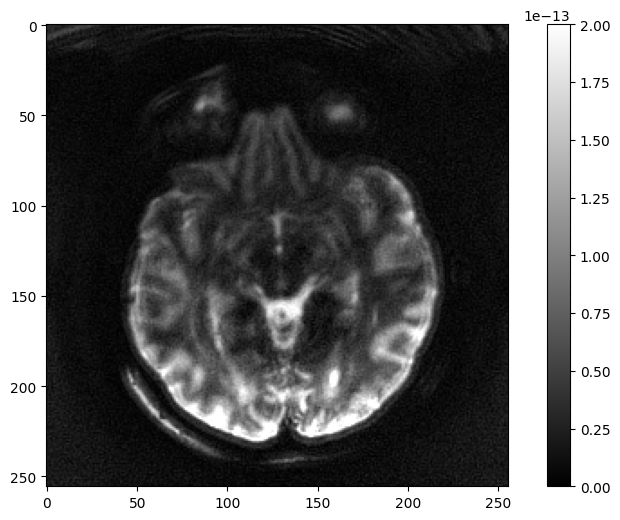

In [804]:
plt.figure(figsize=(10, 6))
# plt.subplot(1, 2, 1)
plt.imshow(np.abs(img_sense_skope_ho_exact[0, 2, 0]), cmap="gray")
# plt.imshow(np.angle(img_exact), cmap="jet")
plt.clim(0, 2e-13)
plt.colorbar()
# plt.axis("off")

# plt.subplot(1, 2, 2)
# plt.imshow(np.angle(img_exact), cmap="jet", vmin=-np.pi, vmax=np.pi)
# plt.title("HO segmented case | Phase")
# plt.axis("off")
# plt.tight_layout()
# plt.show()